# TFG
## Analisis de Datos
### <font color='red'>S01: Empresas y Datos</font>

In [11]:
# No warnings
import warnings
warnings.filterwarnings("ignore")


## Seleccion de Empresa

In [13]:
import pandas as pd

## leer los datos del Russell_2000
# excel
R2000 = pd.read_excel('/content/russell_2000_TFG26.xlsx')
R2000


FileNotFoundError: [Errno 2] No such file or directory: '/content/russell_2000_TFG26.xlsx'

## Leer datos de la Empresa

In [1]:
# leer datos de Yfinance
# !pip install yfinance

import yfinance as yf

# leer datos de STRL
empresa='STRL'
inicio='2015-01-01'
fin='2025-12-31'
periodo='1mo'

precio=yf.download(empresa, start=inicio, end=fin, interval=periodo,auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [2]:
precio.to_excel('/content/precio.xlsx')

In [3]:
print(precio.head())

Price      Adj Close Close  High   Low  Open   Volume
Ticker          STRL  STRL  STRL  STRL  STRL     STRL
Date                                                 
2015-01-01      3.47  3.47  6.45  3.44  6.45  2019000
2015-02-01      2.76  2.76  3.51  2.72  3.47  3952700
2015-03-01      4.52  4.52  4.76  2.23  2.75  8526500
2015-04-01      4.39  4.39  4.91  3.88  4.54  2466100
2015-05-01      3.96  3.96  4.49  3.05  4.40  3184000


In [4]:
print(precio.tail())

Price        Adj Close       Close        High         Low        Open  \
Ticker            STRL        STRL        STRL        STRL        STRL   
Date                                                                     
2025-08-01  278.529999  278.529999  321.790009  244.020004  255.009995   
2025-09-01  339.679993  339.679993  376.750000  266.130005  271.769989   
2025-10-01  377.899994  377.899994  409.329987  315.970001  334.920013   
2025-11-01  344.309998  344.309998  419.140015  299.640015  380.100006   
2025-12-01  306.230011  306.230011  343.799988  281.579987  332.140015   

Price         Volume  
Ticker          STRL  
Date                  
2025-08-01  11224000  
2025-09-01  11887600  
2025-10-01  10716200  
2025-11-01  17940300  
2025-12-01  13558200  


## Calcular rentabilidad logaritmica

In [5]:
# calcular la rentabilidad diaria logaritmica
import numpy as np

rent=np.log(precio['Adj Close']/precio['Adj Close'].shift(1))


# Visualizacion

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns


<Figure size 1000x600 with 0 Axes>

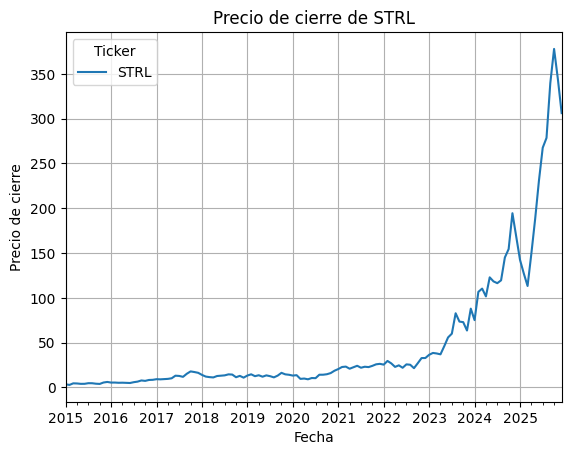

In [7]:
# Grafico del precio de Sterling Infrastructure
plt.figure(figsize=(10, 6))
precio['Adj Close'].plot()
plt.title('Precio de cierre de STRL')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.grid()
plt.savefig('/content/Precio_STRL.png') # grabar el grafico
plt.show()

<Figure size 1000x600 with 0 Axes>

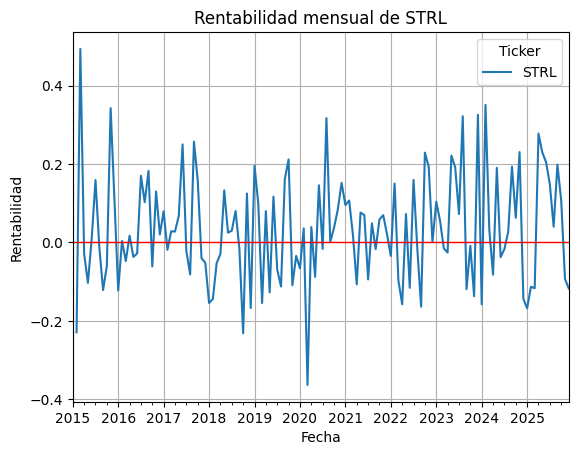

In [8]:
# Grafico de la rentabilidad de Sterling Infrastructure
plt.figure(figsize=(10, 6))
rent.plot()
plt.title('Rentabilidad mensual de STRL')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad')
plt.axhline(0, color='red', lw=1) #linea en zero
plt.grid()
plt.savefig('/content/Rentabilidad_STRL.png') # grabar el grafico
plt.show()

In [14]:
# crear un dataframe con la rentabilidad
df_rent=pd.DataFrame(rent)
df_rent.columns=['Rentabilidad']
df_rent

,Rentabilidad
Date,
2015-01-01,NaN
2015-02-01,-0.228924
2015-03-01,0.493281
2015-04-01,-0.029183
2015-05-01,-0.103085
...,...
2025-08-01,0.040070
2025-09-01,0.198478
2025-10-01,0.106626


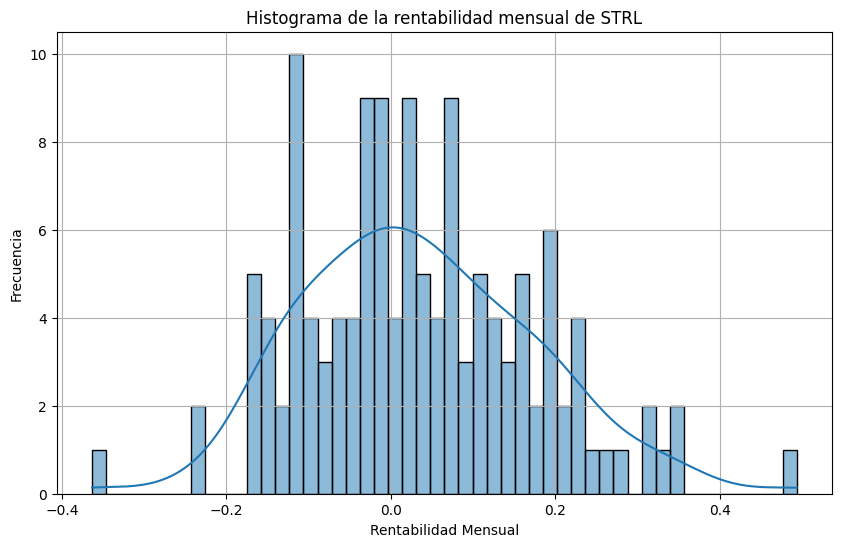

In [15]:
# Histograma de la rentabilidad diaria y densidad de probabilidad
plt.figure(figsize=(10, 6))
sns.histplot(data=df_rent, x='Rentabilidad', bins=50, kde=True)
plt.title('Histograma de la rentabilidad mensual de STRL')
plt.xlabel('Rentabilidad Mensual')
plt.ylabel('Frecuencia')
plt.grid()
plt.savefig('/content/Histograma_Rentabilidad_STRL.png')
plt.show()

# R2000
El índice Russell 2000 es un índice del mercado de valores estadounidense de pequeña capitalización que constituye las 2000 acciones más pequeñas del índice Russell.
Fue iniciado por Frank Russell Company en 1984.
El índice lo mantiene FTSE Russell, una subsidiaria del London Stock Exchange Group.

In [16]:
# leer datos de R2000
ticker='^RUT'
inicio='2015-01-01'
fin='2025-12-31'
periodo='1mo'

indice=yf.download(ticker, start=inicio, end=fin, interval=periodo,auto_adjust=False)


[*********************100%***********************]  1 of 1 completed


In [18]:
indice.to_excel('/content/indice.xlsx')

<Figure size 1000x600 with 0 Axes>

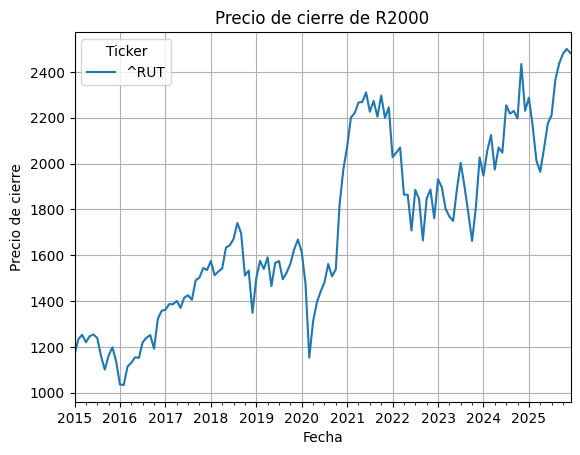

In [17]:
# Grafico del precio de R2000
plt.figure(figsize=(10, 6))
indice['Adj Close'].plot()
plt.title('Precio de cierre de R2000')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.grid()
plt.savefig('/content/Precio_R2000.png') # grabar el grafico
plt.show()

In [19]:
# calcular la rentabilidad diaria logaritmica

rentI=np.log(indice['Adj Close']/indice['Adj Close'].shift(1))
# crear un dataframe con la rentabilidad
df_rentI=pd.DataFrame(rentI)
df_rentI.columns=['Rentabilidad']
df_rentI

,Rentabilidad
Date,
2015-01-01,NaN
2015-02-01,0.056694
2015-03-01,0.015607
2015-04-01,-0.026400
2015-05-01,0.021406
...,...
2025-08-01,0.067639
2025-09-01,0.029176
2025-10-01,0.017454


<Figure size 1000x600 with 0 Axes>

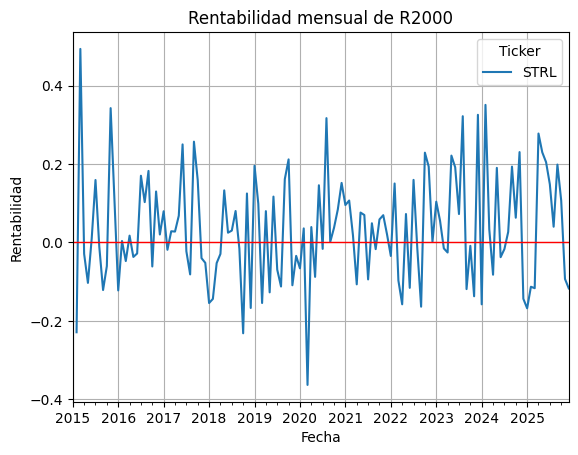

In [20]:
# Grafico de la rentabilidad de R2000
plt.figure(figsize=(10, 6))
rent.plot()
plt.title('Rentabilidad mensual de R2000')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad')
plt.axhline(0, color='red', lw=1) #linea en zero
plt.grid()
plt.savefig('/content/Rentabilidad_R2000.png') # grabar el grafico
plt.show()

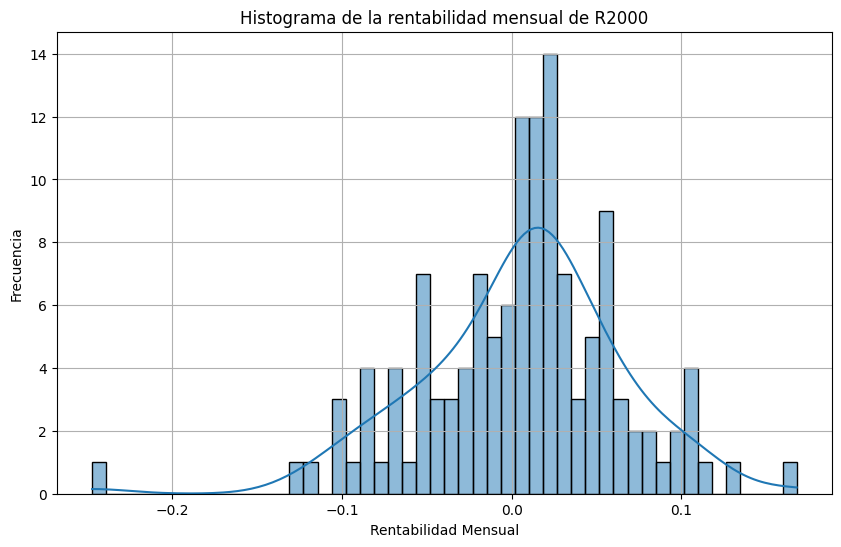

In [21]:
# Histograma de la rentabilidad diaria y densidad de probabilidad
plt.figure(figsize=(10, 6))
sns.histplot(data=df_rentI, x='Rentabilidad', bins=50, kde=True)
plt.title('Histograma de la rentabilidad mensual de R2000')
plt.xlabel('Rentabilidad Mensual')
plt.ylabel('Frecuencia')
plt.grid()
plt.savefig('/content/Histograma_Rentabilidad_R2000.png')
plt.show()

In [22]:
# Crear un dataframe con los precios y las rentabildades
df=pd.DataFrame()
df['STRL']=precio['Adj Close']
df['R2000']=indice['Adj Close']
df['Rentabilidad_STRL']=rent
df['Rentabilidad_R2000']=rentI
df



,STRL,R2000,Rentabilidad_STRL,Rentabilidad_R2000
Date,,,,
2015-01-01,3.470000,1165.390015,NaN,NaN
2015-02-01,2.760000,1233.369995,-0.228924,0.056694
2015-03-01,4.520000,1252.770020,0.493281,0.015607
2015-04-01,4.390000,1220.130005,-0.029183,-0.026400
2015-05-01,3.960000,1246.530029,-0.103085,0.021406
...,...,...,...,...
2025-08-01,278.529999,2366.419922,0.040070,0.067639
2025-09-01,339.679993,2436.479980,0.198478,0.029176
2025-10-01,377.899994,2479.379883,0.106626,0.017454


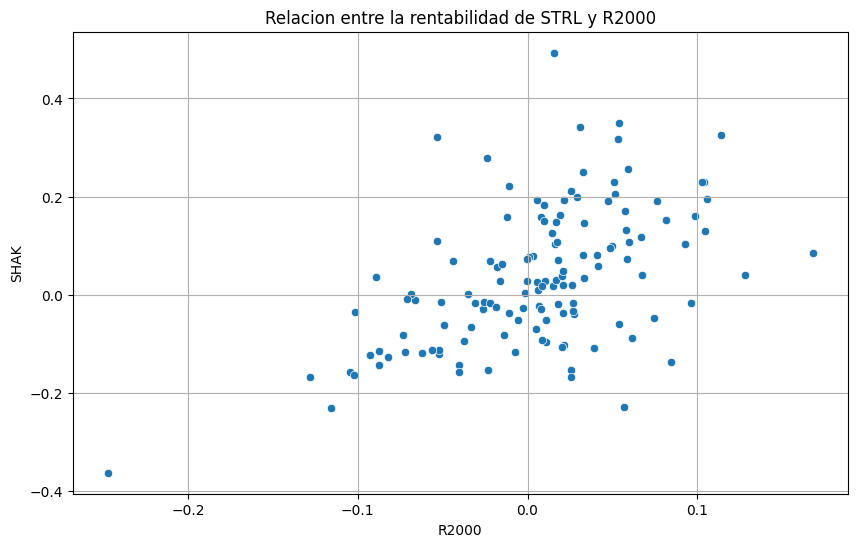

In [23]:
# scatter del russell 2000 y Sterling Infrastructure
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rentabilidad_R2000', y='Rentabilidad_STRL')
plt.title('Relacion entre la rentabilidad de STRL y R2000')
plt.xlabel('R2000')
plt.ylabel('SHAK')
plt.grid()
plt.savefig('/content/STRL_R2000.png')
plt.show()


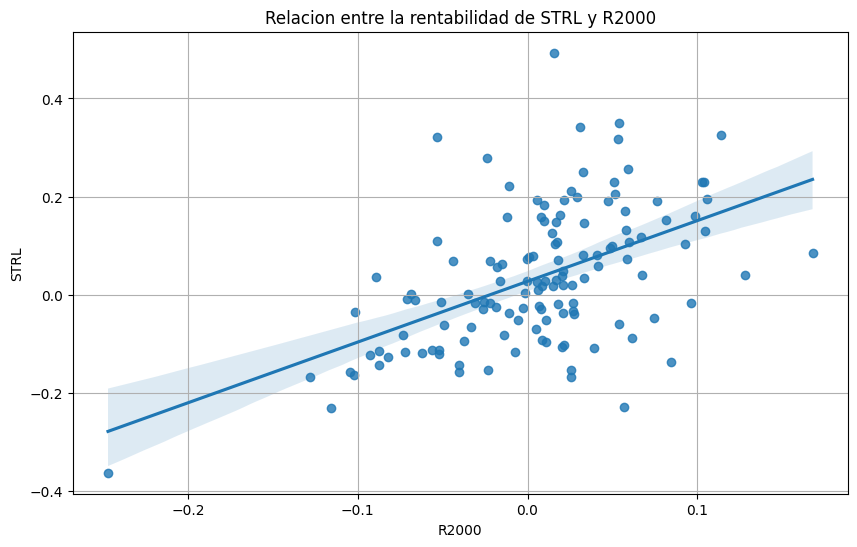

In [24]:
# scatter del russell 2000 y Sterling Infrastructure con recta de regersión
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Rentabilidad_R2000', y='Rentabilidad_STRL')
plt.title('Relacion entre la rentabilidad de STRL y R2000')
plt.xlabel('R2000')
plt.ylabel('STRL')
# mostar regresion
plt.savefig('/content/STRL_R2000_recta.png')
plt.grid()
plt.show()


In [25]:
#Guardar datos
df.to_csv('/content/datos_strl_tfg.csv', index=True)

In [26]:
import pandas as pd
import numpy as np
import datetime


In [27]:
# Definir el período de 10 años
end_date = '2025-12-31'
start_date = '2015-01-01'


In [28]:
returns = pd.read_csv('/content/datos_strl_tfg.csv')
#index date
returns['Date'] = pd.to_datetime(returns['Date'])
returns.set_index('Date', inplace=True)
returns


,STRL,R2000,Rentabilidad_STRL,Rentabilidad_R2000
Date,,,,
2015-01-01,3.470000,1165.390015,NaN,NaN
2015-02-01,2.760000,1233.369995,-0.228924,0.056694
2015-03-01,4.520000,1252.770020,0.493281,0.015607
2015-04-01,4.390000,1220.130005,-0.029183,-0.026400
2015-05-01,3.960000,1246.530029,-0.103085,0.021406
...,...,...,...,...
2025-08-01,278.529999,2366.419922,0.040070,0.067639
2025-09-01,339.679993,2436.479980,0.198478,0.029176
2025-10-01,377.899994,2479.379883,0.106626,0.017454


In [29]:
# !pip install pandas-datareader
# Obtener datos de Fama-French (descarga desde web)
import pandas_datareader.data as web
# Obtener datos de Fama-French desde DataReader
fama_french = web.DataReader("F-F_Research_Data_Factors", "famafrench", start_date, end_date)[0]

# Convertir índice a formato de fecha
fama_french.index = fama_french.index.to_timestamp()

# Convertir retornos de Fama-French a porcentajes
fama_french = fama_french / 100


In [30]:

# Alinear fechas con Fama-French
returns = returns.join(fama_french, how="inner")

# Calcular primas de mercado y de Shake Shack
returns["Market Premium"] = returns["Rentabilidad_R2000"] - returns["RF"]
returns["STRL Premium"] = returns["Rentabilidad_STRL"] - returns["RF"]

# Mostrar resultados
returns

,STRL,R2000,Rentabilidad_STRL,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,STRL Premium
Date,,,,,,,,,,
2015-01-01,3.470000,1165.390015,NaN,NaN,-0.0310,-0.0059,-0.0345,0.0000,NaN,NaN
2015-02-01,2.760000,1233.369995,-0.228924,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,-0.228924
2015-03-01,4.520000,1252.770020,0.493281,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,0.493281
2015-04-01,4.390000,1220.130005,-0.029183,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,-0.029183
2015-05-01,3.960000,1246.530029,-0.103085,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,-0.103085
...,...,...,...,...,...,...,...,...,...,...
2025-08-01,278.529999,2366.419922,0.040070,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.036270
2025-09-01,339.679993,2436.479980,0.198478,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.195178
2025-10-01,377.899994,2479.379883,0.106626,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,0.102926


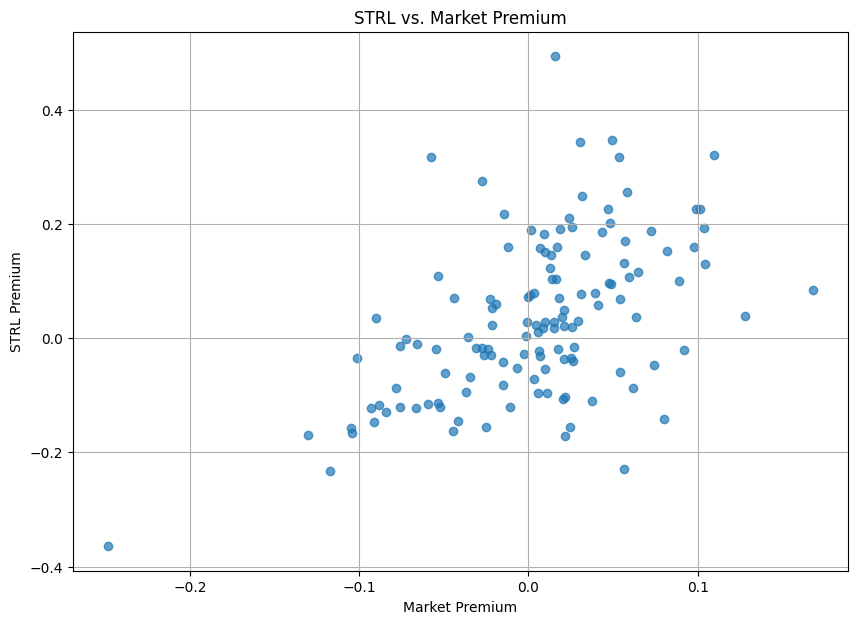

In [31]:
# Gráfico XY
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(returns["Market Premium"], returns["STRL Premium"], alpha=0.7)
plt.xlabel("Market Premium")
plt.ylabel("STRL Premium")
plt.title("STRL vs. Market Premium")
plt.grid(True)
plt.show()


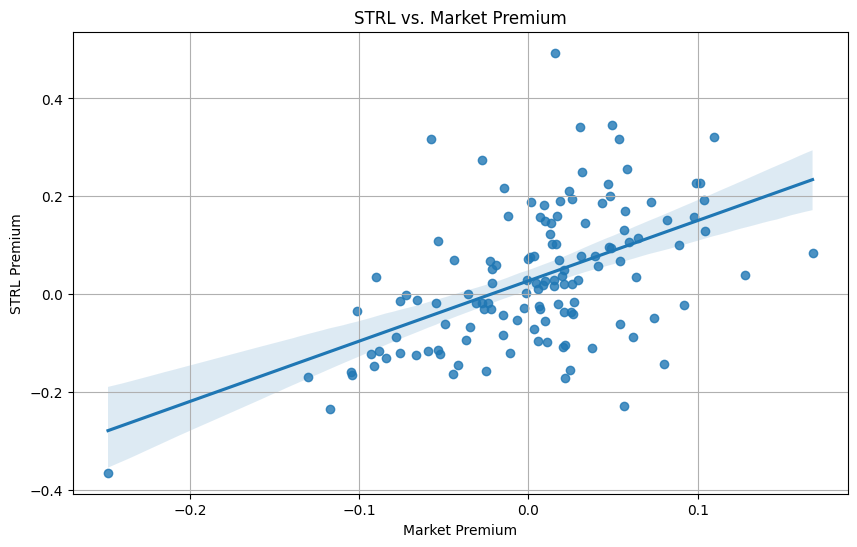

In [32]:
# Grafico con regresión lineal usando sns.regplot
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.regplot(x="Market Premium", y="STRL Premium", data=returns)
plt.xlabel("Market Premium")
plt.ylabel("STRL Premium")
plt.title("STRL vs. Market Premium")
plt.grid(True)
plt.show()


In [33]:
# Estimar la regresión
import statsmodels.api as sm
modelo_capm = sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium']", data=returns).fit()
modelo_capm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.268
Model:                                 OLS   Adj. R-squared:                  0.262
Method:                      Least Squares   F-statistic:                     47.19
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           2.46e-10
Time:                             17:43:09   Log-Likelihood:                 92.371
No. Observations:                      131   AIC:                            -180.7
Df Residuals:                          129   BIC:                            -175.0
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0275      0.011      2.603      0.010       0.007       0.048
returns['Market Premium']     1.2315      0.179      6.869      0.000       0.877       1.586
==============================================================================
Omnibus:                       12.988   Durbin-Watson:                   2.087
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.925
Skew:                           0.569   Prob(JB):                     0.000211
Kurtosis:                       4.344   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

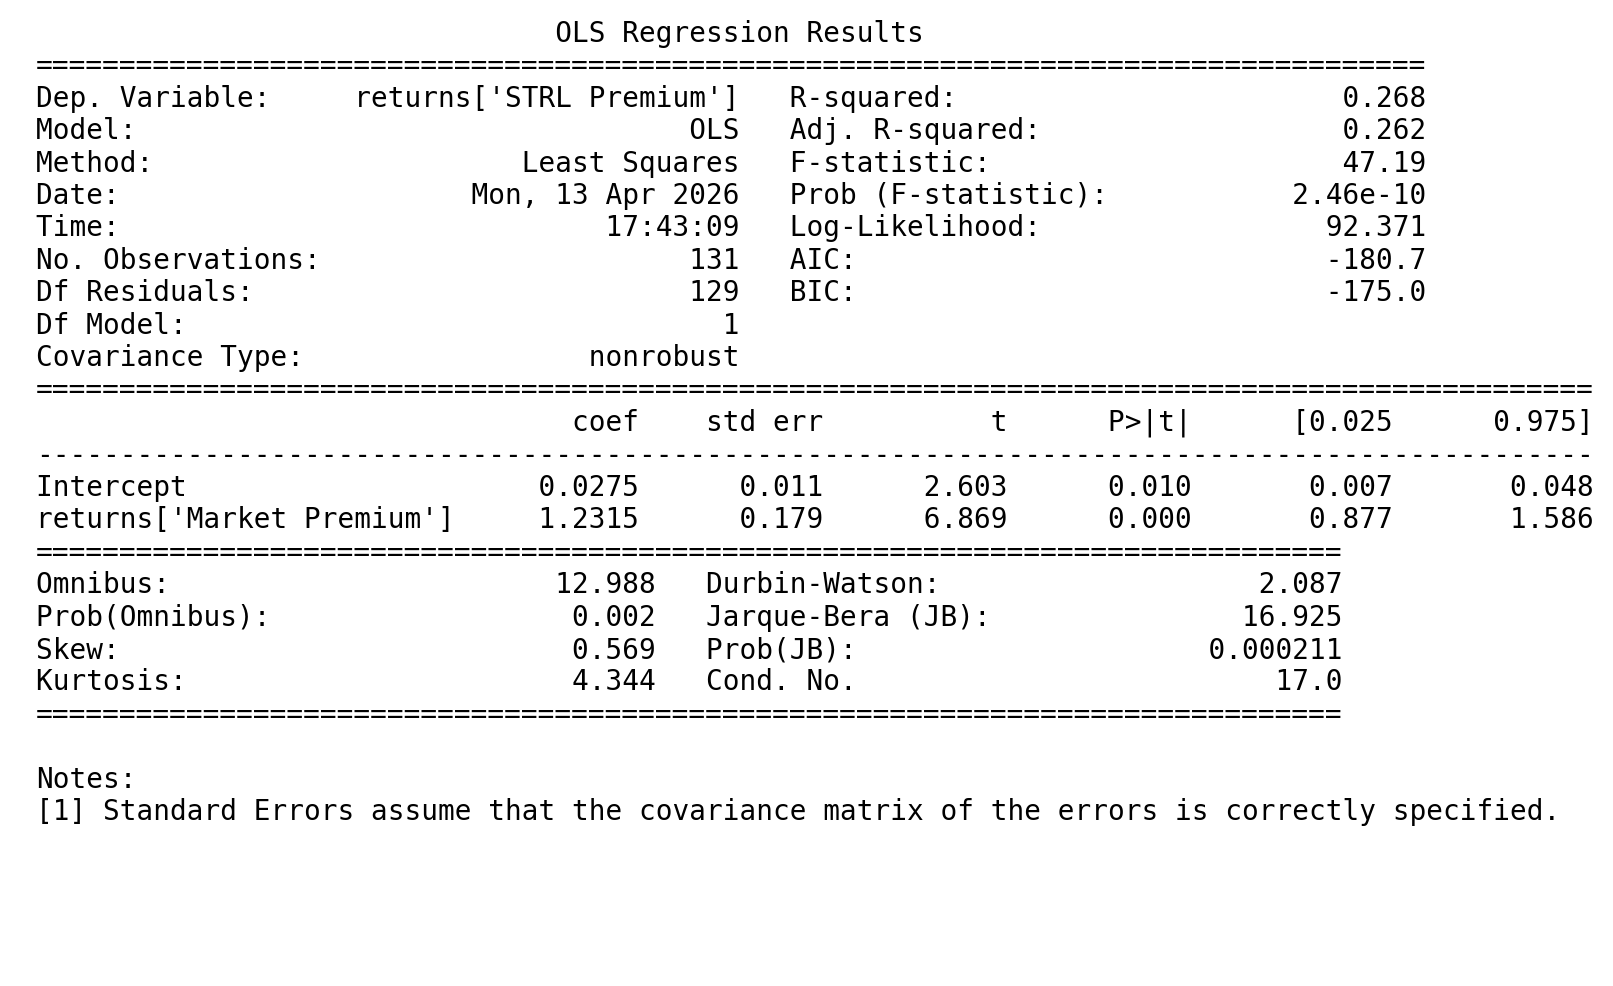

In [34]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.99, modelo_capm.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/regresion_capm_01.png')

## 📊 Conclusiones: Estimación inicial CAPM (OLS sin corrección)

La estimación inicial del modelo CAPM para **Sterling Infrastructure (STRL)** sobre el período enero 2015 – diciembre 2025 (131 observaciones mensuales) arroja los siguientes resultados:

**Ecuación estimada:**
$$\text{STRL Premium}_t = 0.0275 + 1.2315 \cdot \text{Market Premium}_t + \varepsilon_t$$

| Parámetro | Coef. | t | p-valor | Interpretación |
|-----------|-------|---|---------|----------------|
| **Alpha** | 0.0275 | 2.603 | 0.010 | Significativo al 5%. STRL genera una rentabilidad mensual media de +2.75% por encima de lo que predice el CAPM. |
| **Beta** | 1.2315 | 6.869 | 0.000 | Altamente significativo. STRL es más volátil que el Russell 2000 (β > 1). |

- **R² = 0.268**: El modelo explica el 26.8% de la variabilidad de la rentabilidad en exceso de STRL.
- **F = 47.19** (p ≈ 0): el modelo es globalmente significativo.

⚠️ Los errores estándar son **no robustos**. El test de Jarque-Bera rechaza la normalidad de los residuos (p = 0.0002). Se procede al diagnóstico completo de residuos antes de usar esta estimación para inferencia.


In [35]:
# save data como dataframe
returns.to_csv('/content/returns.csv')

# Analisis de Residuos

In [36]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [37]:
# leer datos
returns = pd.read_csv('returns.csv')

In [35]:
returns

,Date,STRL,R2000,Rentabilidad_STRL,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,STRL Premium
0,2015-01-01,3.470000,1165.390015,NaN,NaN,-0.0310,-0.0059,-0.0345,0.0000,NaN,NaN
1,2015-02-01,2.760000,1233.369995,-0.228924,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,-0.228924
2,2015-03-01,4.520000,1252.770020,0.493281,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,0.493281
3,2015-04-01,4.390000,1220.130005,-0.029183,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,-0.029183
4,2015-05-01,3.960000,1246.530029,-0.103085,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,-0.103085
...,...,...,...,...,...,...,...,...,...,...,...
127,2025-08-01,278.529999,2366.419922,0.040070,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.036270
128,2025-09-01,339.679993,2436.479980,0.198478,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.195178
129,2025-10-01,377.899994,2479.379883,0.106626,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,0.102926
130,2025-11-01,344.309998,2500.429932,-0.093087,0.008454,-0.0013,0.0038,0.0376,0.0030,0.005454,-0.096087


In [38]:
# Eliminar NA`s
returns=returns.dropna()

In [39]:
# Estimar la regresión
import statsmodels.api as sm
modelo_capm = sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium']", data=returns).fit()
modelo_capm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.268
Model:                                 OLS   Adj. R-squared:                  0.262
Method:                      Least Squares   F-statistic:                     47.19
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           2.46e-10
Time:                             17:43:22   Log-Likelihood:                 92.371
No. Observations:                      131   AIC:                            -180.7
Df Residuals:                          129   BIC:                            -175.0
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0275      0.011      2.603      0.010       0.007       0.048
returns['Market Premium']     1.2315      0.179      6.869      0.000       0.877       1.586
==============================================================================
Omnibus:                       12.988   Durbin-Watson:                   2.087
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.925
Skew:                           0.569   Prob(JB):                     0.000211
Kurtosis:                       4.344   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

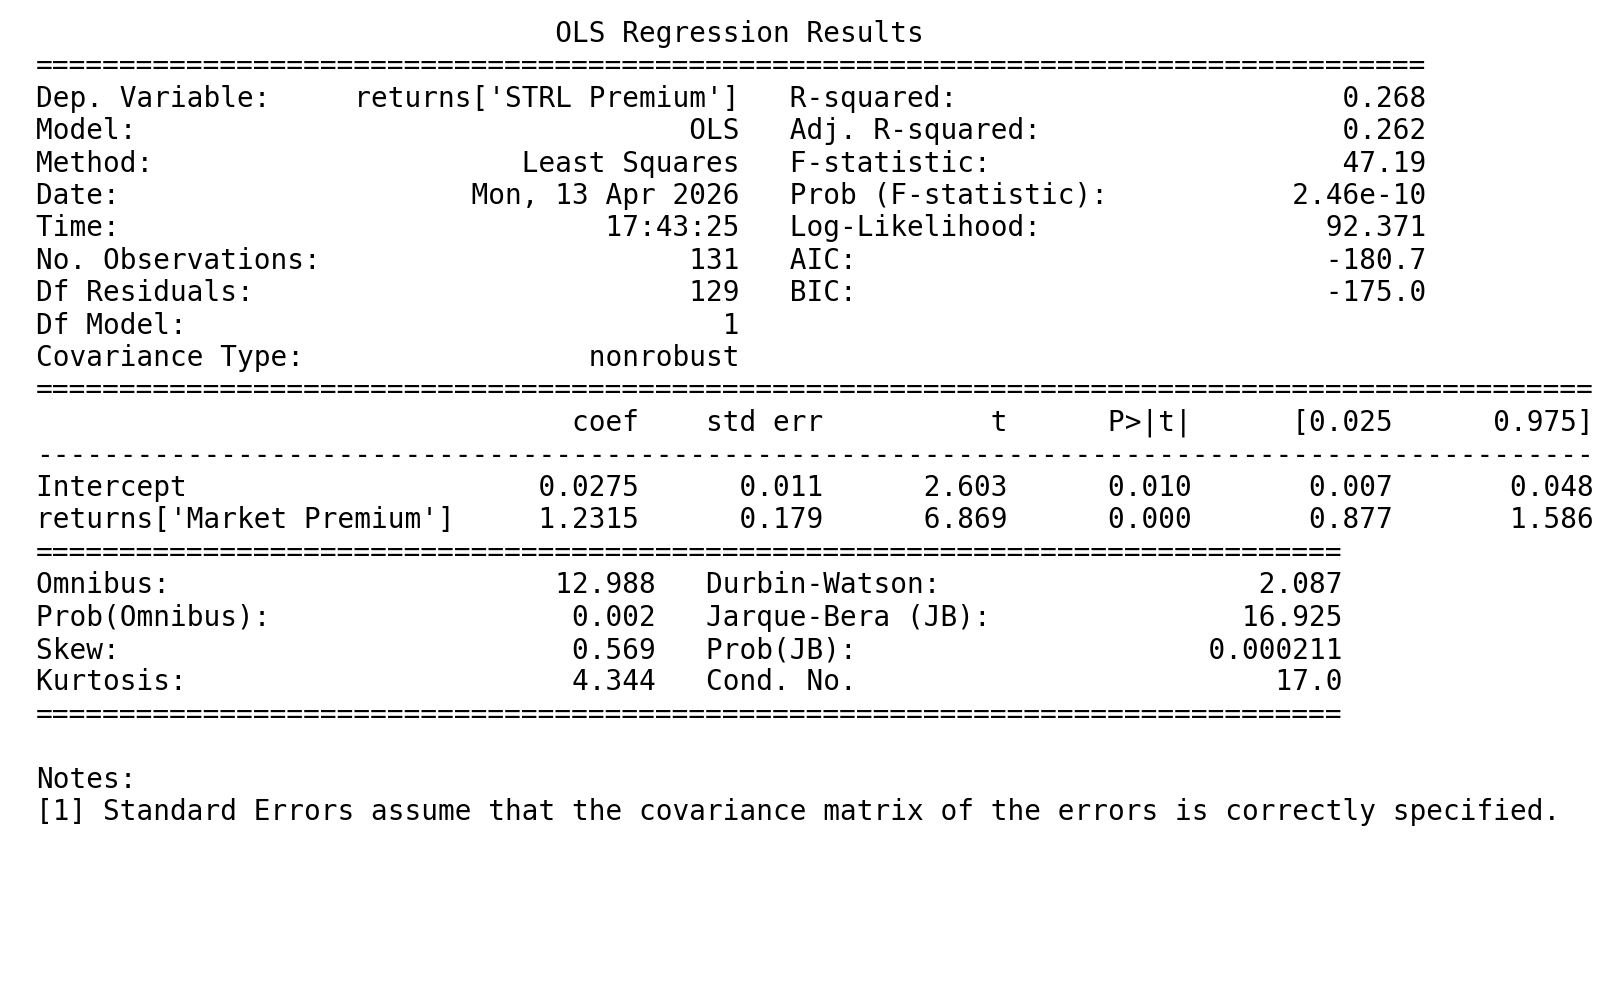

In [40]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.99, modelo_capm.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/regresion_capm_02.png')


In [41]:
# Generar los residuos
returns.index=returns['Date']
returns['residuos'] = modelo_capm.resid.values
returns


,Date,STRL,R2000,Rentabilidad_STRL,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,STRL Premium,residuos
Date,,,,,,,,,,,,
2015-02-01,2015-02-01,2.760000,1233.369995,-0.228924,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,-0.228924,-0.326208
2015-03-01,2015-03-01,4.520000,1252.770020,0.493281,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,0.493281,0.446598
2015-04-01,2015-04-01,4.390000,1220.130005,-0.029183,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,-0.029183,-0.024133
2015-05-01,2015-05-01,3.960000,1246.530029,-0.103085,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,-0.103085,-0.156911
2015-06-01,2015-06-01,4.000000,1253.949951,0.010050,0.005935,-0.0152,0.0294,-0.0082,0.0000,0.005935,0.010050,-0.024721
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,2025-08-01,278.529999,2366.419922,0.040070,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.036270,-0.069814
2025-09-01,2025-09-01,339.679993,2436.479980,0.198478,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.195178,0.135848
2025-10-01,2025-10-01,377.899994,2479.379883,0.106626,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,0.102926,0.058524


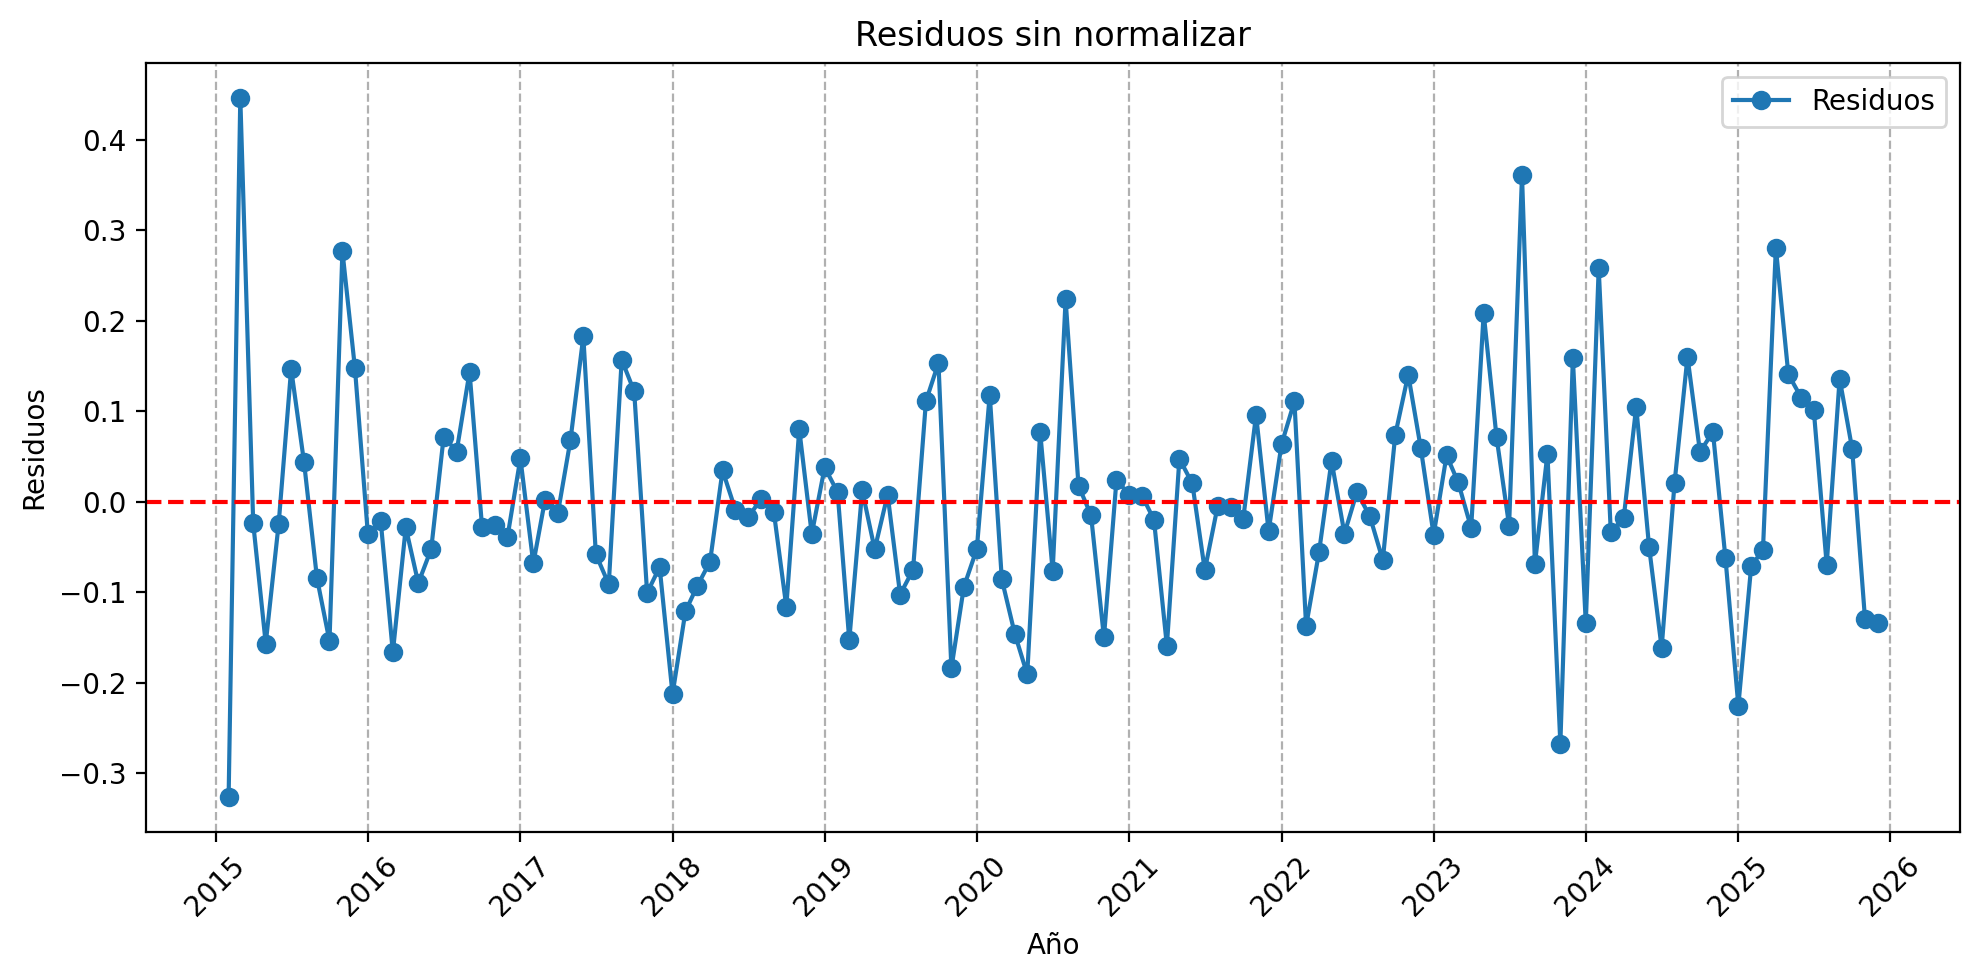

In [42]:
import matplotlib.dates as mdates

# Primero,  el índice sea de tipo datetime
if not isinstance(returns.index, pd.DatetimeIndex):
    # Si tu índice no es de tipo datetime, conviértelo
    returns.index = pd.to_datetime(returns.index)

# Configuración de los ticks y el grid en el inicio de cada año
year_locator = mdates.YearLocator()  # Localizador para cada inicio de año
year_formatter = mdates.DateFormatter('%Y')  # Formateador para mostrar solo el año

# Graficar residuos sin normalizar
plt.figure(figsize=(10, 5))
plt.plot(returns['residuos'], marker='o', linestyle='-', label='Residuos')
plt.axhline(0, color='red', linestyle='--')

# Configurar el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(year_locator)  # Ticks en cada año
ax.xaxis.set_major_formatter(year_formatter)  # Mostrar solo el año
plt.grid(True, which='major', axis='x', linestyle='--')  # Grid en los inicios de año

# Rotar las etiquetas del eje x si  para mayor claridad
plt.xticks(rotation=45)

plt.title('Residuos sin normalizar')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.legend()
plt.tight_layout()  # Ajustar el diseño para evitar recortes
plt.savefig('/content/residuos_sin_normalizar.png') # grabar el grafico
plt.show()

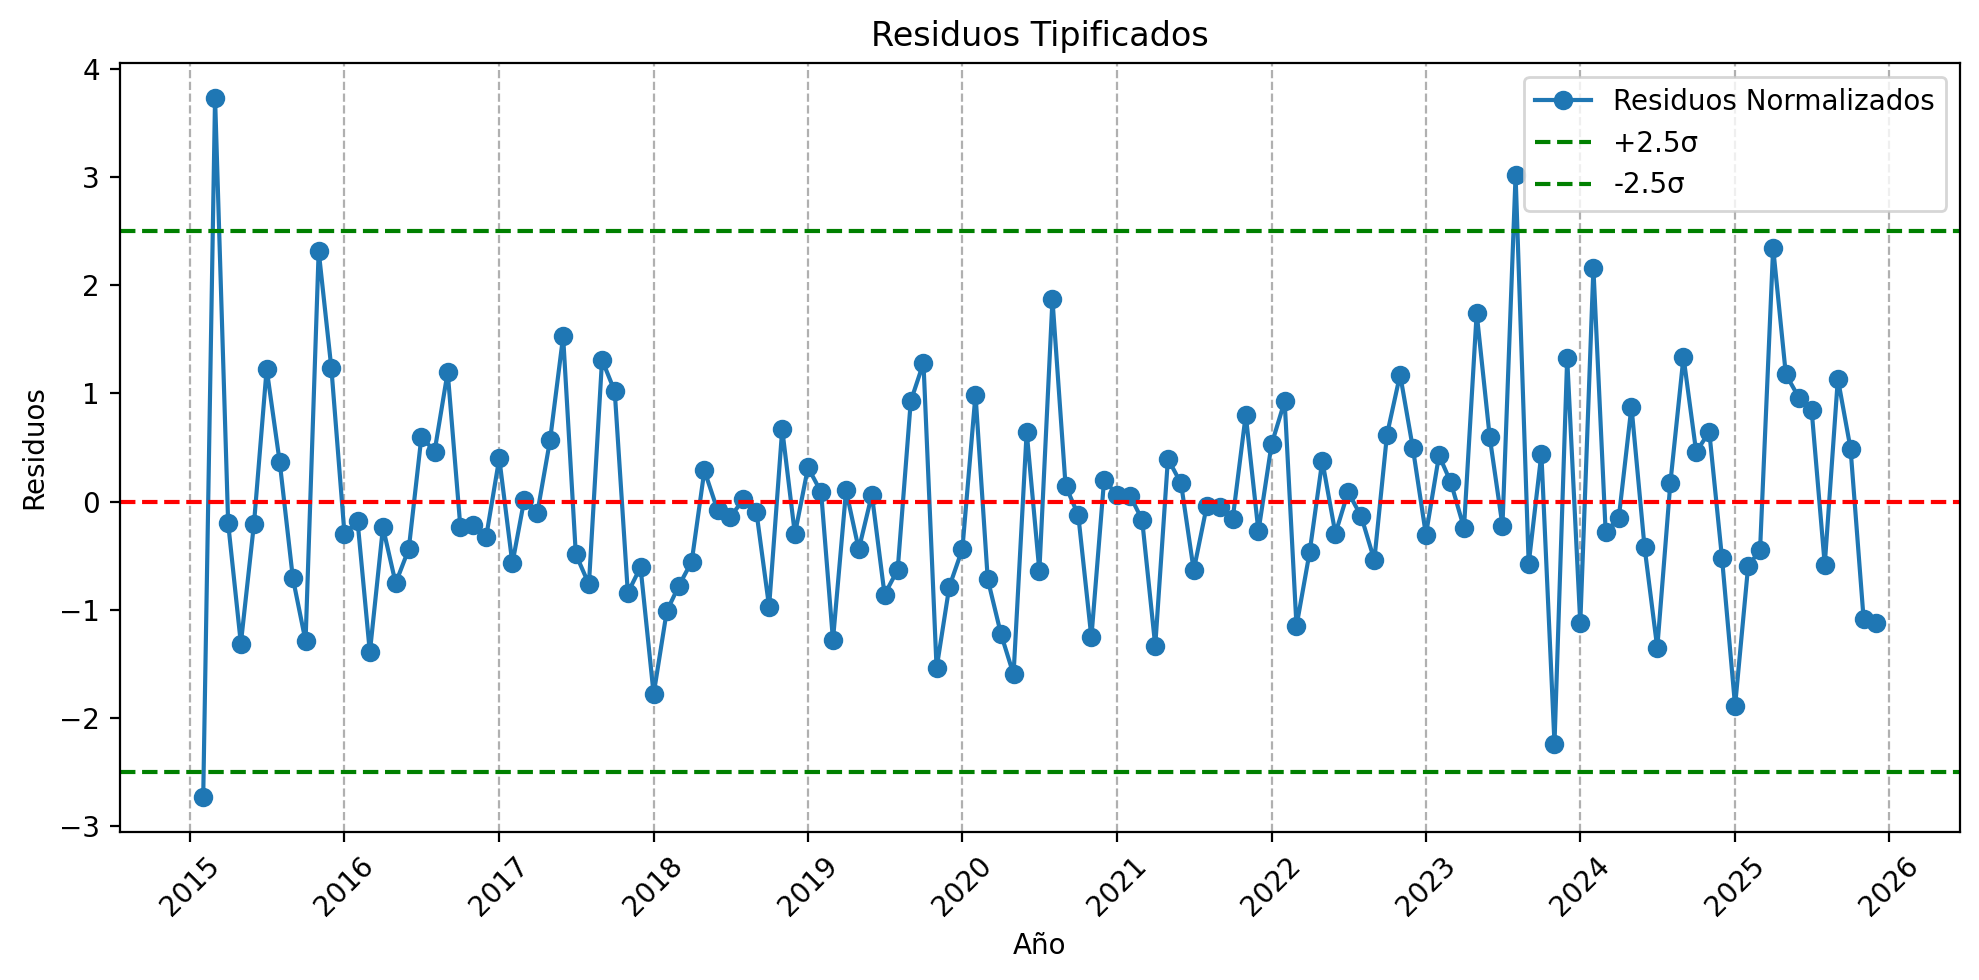

In [43]:
# Normalización de los residuos
returns['residuos_normalizados'] = (returns['residuos'] - np.mean(returns['residuos'])) / np.std(returns['residuos'])

plt.figure(figsize=(10, 5))
plt.plot(returns['residuos_normalizados'], marker='o', linestyle='-', label='Residuos Normalizados')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2.5, color='green', linestyle='--', label='+2.5σ')
plt.axhline(-2.5, color='green', linestyle='--', label='-2.5σ')

# Configurar el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(year_locator)  # Ticks en cada año
ax.xaxis.set_major_formatter(year_formatter)  # Mostrar solo el año
plt.grid(True, which='major', axis='x', linestyle='--')  # Grid en los inicios de año

# Rotar las etiquetas del eje x si  para mayor claridad
plt.xticks(rotation=45)

plt.title('Residuos Tipificados')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.legend()
plt.tight_layout()  # Ajustar el diseño para evitar recortes
plt.savefig('/content/residuos_tipificados.png') # grabar el grafico
plt.show()

## Normalidad

In [44]:
import scipy.stats as stats

from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# Obtener los residuos
residuos = modelo_capm.resid

# 1. Análisis de Normalidad
# ------------------------

# Test de Jarque-Bera para normalidad
jb_test = sm.stats.jarque_bera(residuos)
print(f"Test de Jarque-Bera:")
print(f"Estadístico: {jb_test[0]:.4f}")
print(f"p-valor: {jb_test[1]:.4f}")
print(f"Normalidad: {'Se rechaza' if jb_test[1] < 0.05 else 'No se rechaza'}")
print("\n")


Test de Jarque-Bera:
Estadístico: 16.9254
p-valor: 0.0002
Normalidad: Se rechaza




### 📌 Conclusión: Test de Normalidad (Jarque-Bera)

- **Estadístico JB = 16.93**, **p-valor = 0.0002** → Se **rechaza la normalidad** al 5%.
- Los residuos presentan **asimetría positiva (0.569)** y **exceso de curtosis (4.344)**, indicando colas más pesadas que la distribución normal. Esto es habitual en series de rentabilidades financieras.
- Este resultado implica que los contrastes estándar t/F pueden no ser fiables. Se justifica el uso de **errores robustos HAC (Newey-West)** y la corrección de los outliers detectados.


<Figure size 2000x1200 with 0 Axes>

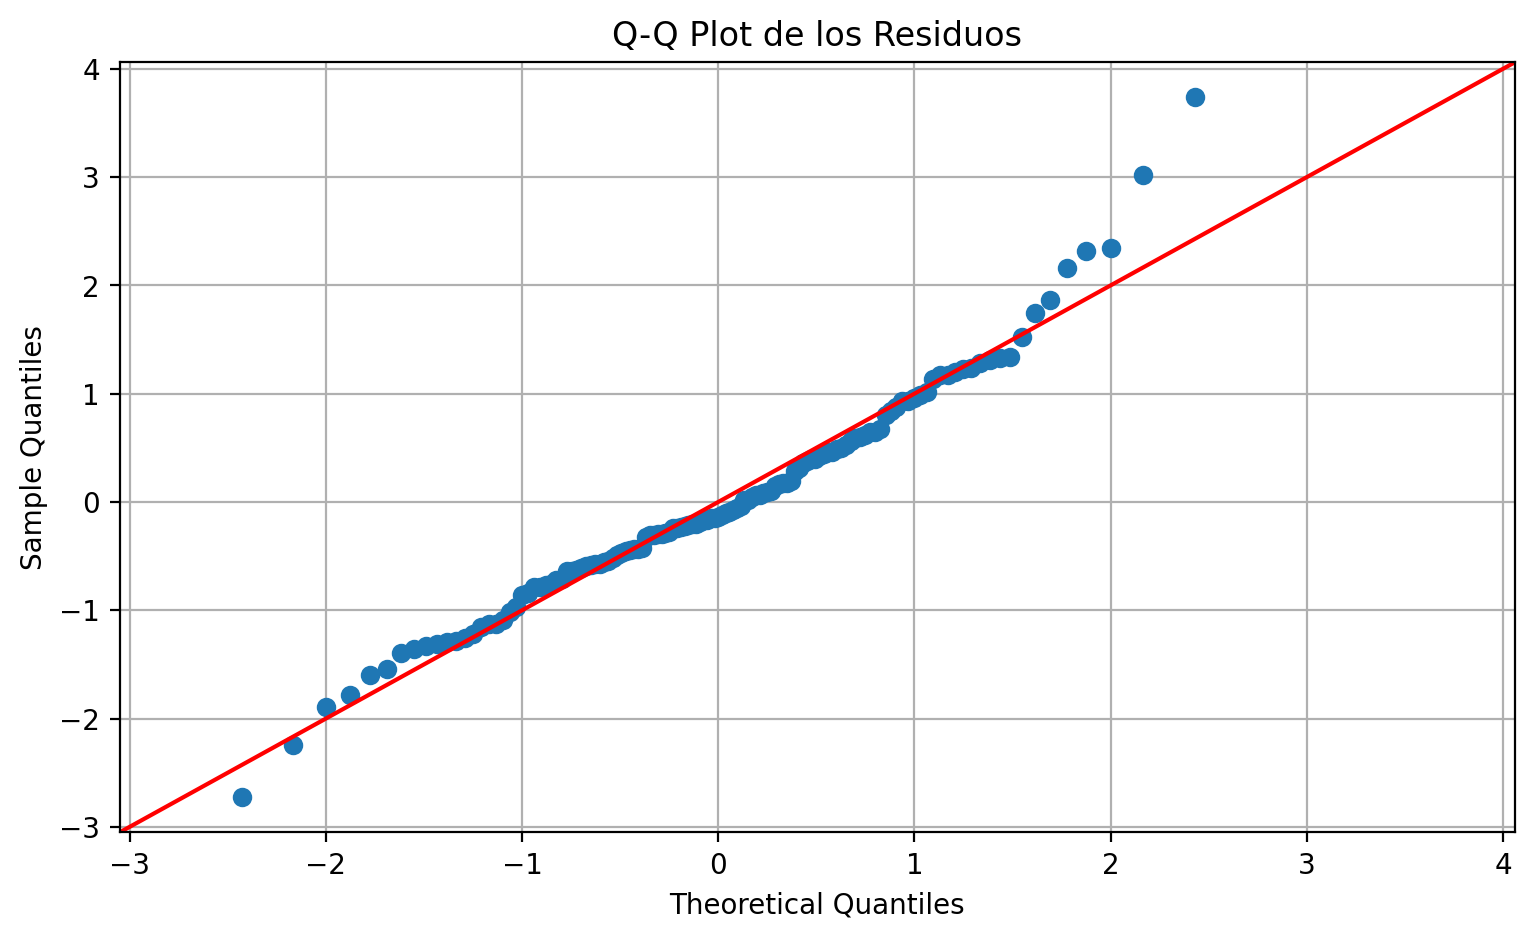

In [45]:

# Gráfico Q-Q Plot
plt.figure(figsize=(10, 6))
fig = sm.qqplot(residuos, stats.norm, line='45', fit=True)
plt.title('Q-Q Plot de los Residuos')
plt.grid(True)
plt.savefig('/content/residuos_qqplot.png') # grabar el grafico
plt.show()


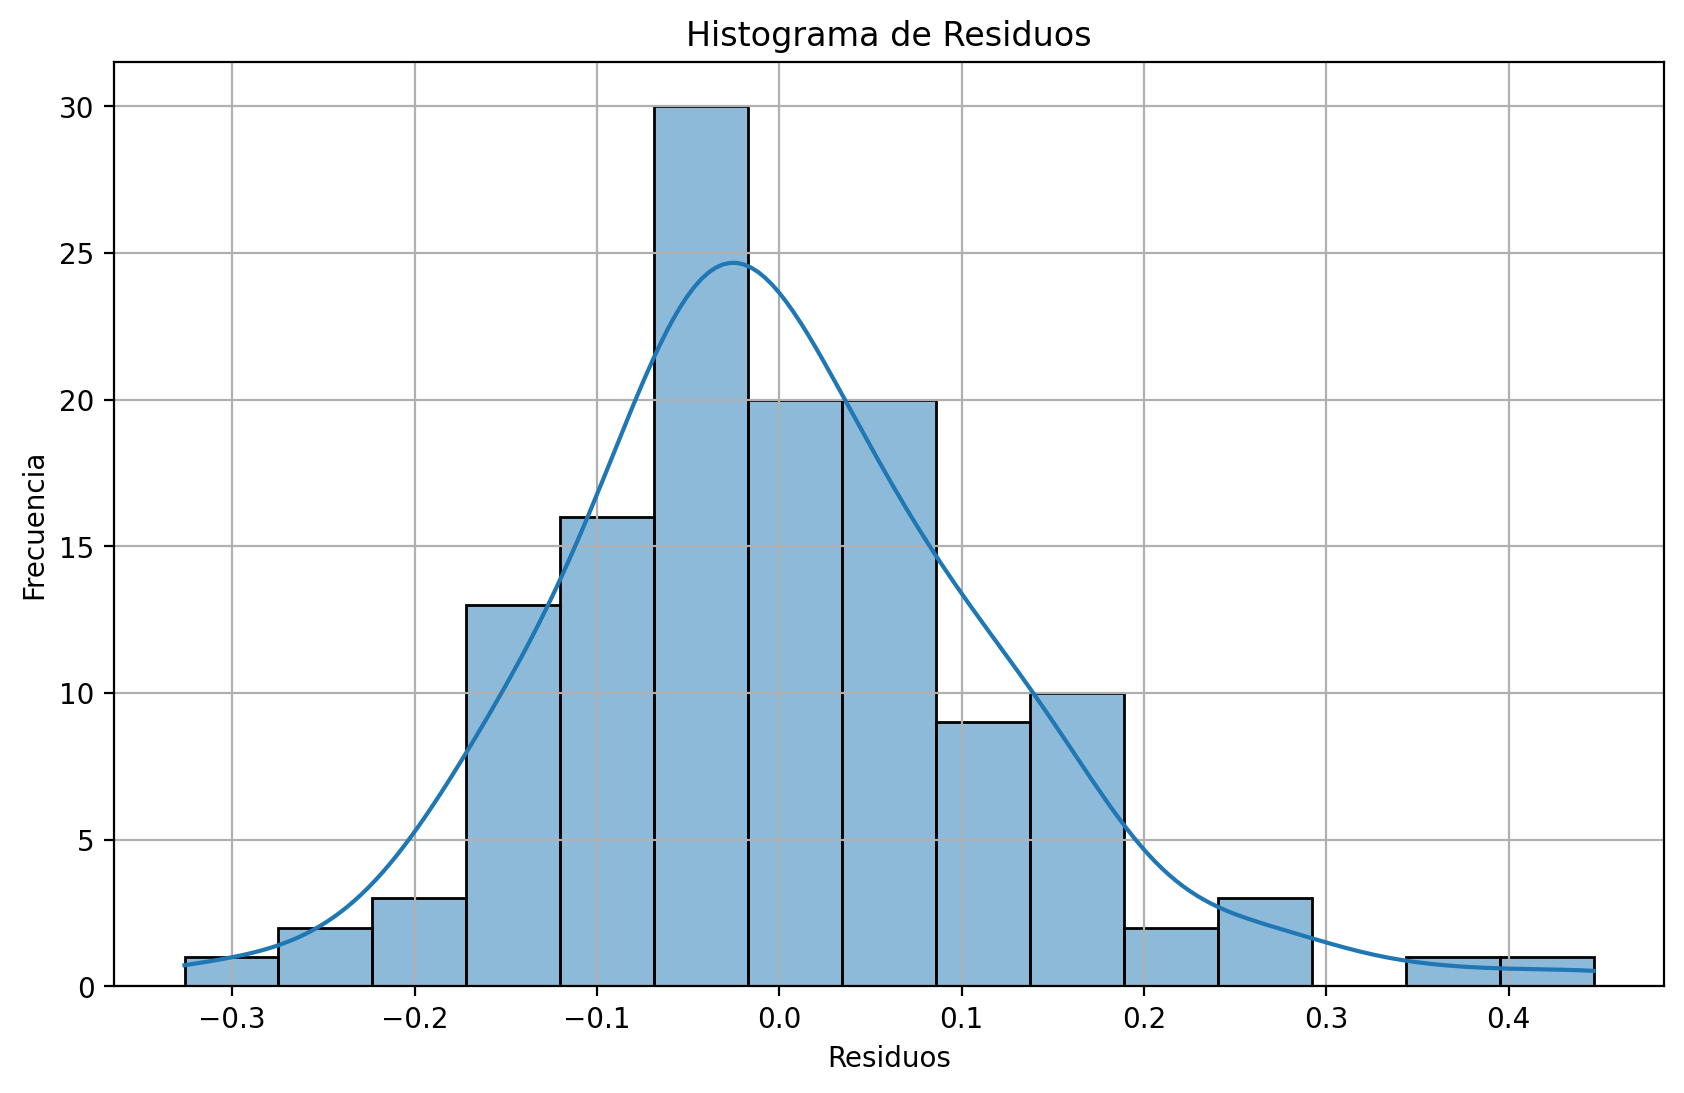

In [46]:
# Histograma de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.savefig('/content/residuos_histograma.png') # grabar el grafico
plt.show()


## Heterocedasticidad

In [47]:
# 2. Análisis de Heterocedasticidad
# ---------------------------------

# Test de Breusch-Pagan
bp_test = het_breuschpagan(residuos, modelo_capm.model.exog)
print(f"Test de Breusch-Pagan para Heterocedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"p-valor: {bp_test[1]:.4f}")
print(f"Homocedasticidad: {'Se rechaza' if bp_test[1] < 0.05 else 'No se rechaza'}")
print("\n")


Test de Breusch-Pagan para Heterocedasticidad:
Estadístico LM: 1.9210
p-valor: 0.1658
Homocedasticidad: No se rechaza




### 📌 Conclusión: Tests de Heterocedasticidad

**Breusch-Pagan:** LM = 1.921, **p-valor = 0.1658** → No se rechaza homocedasticidad.  
**White:** LM = 1.948, **p-valor = 0.3777** → No se rechaza homocedasticidad.

**Conclusión:** No existe evidencia de heterocedasticidad en los residuos de STRL. La varianza de los errores es constante a lo largo del período.


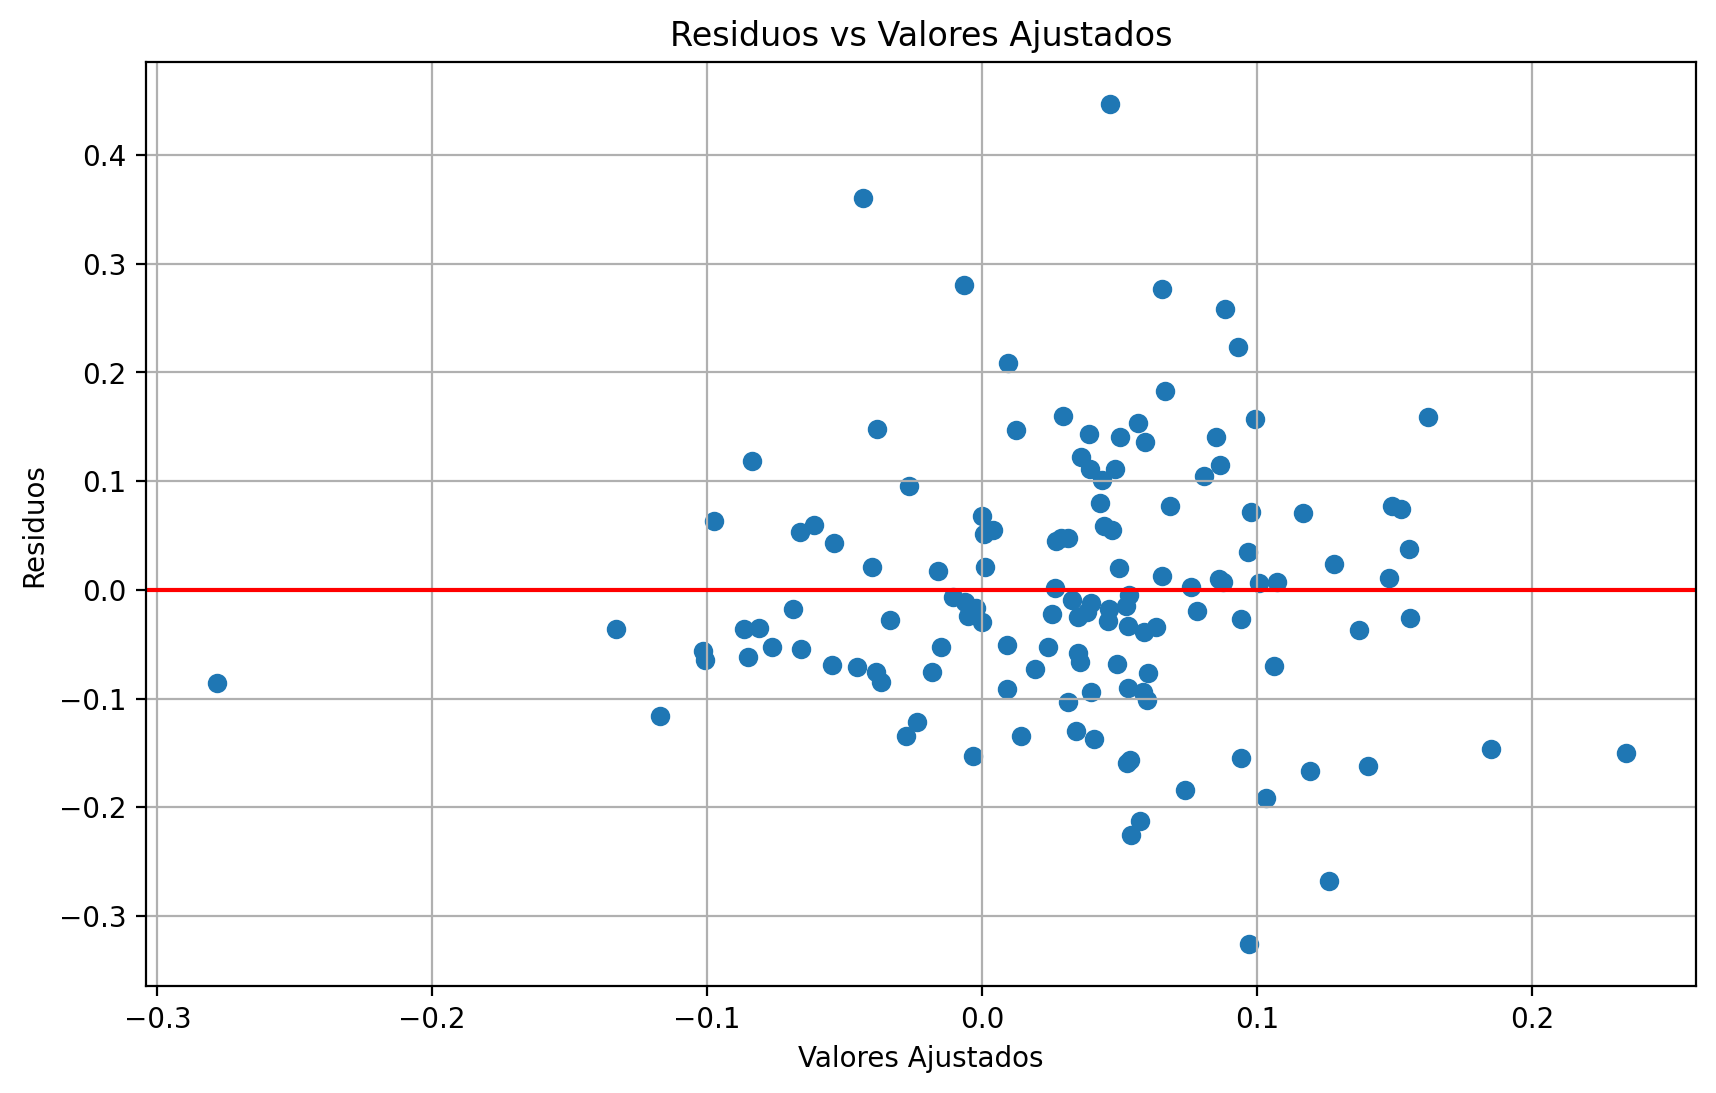

In [48]:
# Gráfico de residuos vs valores ajustados
plt.figure(figsize=(10, 6))
plt.scatter(modelo_capm.fittedvalues, residuos)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuos vs Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.grid(True)
plt.savefig('/content/residuos_valoresajustados.png') # grabar el grafico
plt.show()


In [49]:
from statsmodels.stats.diagnostic import het_white

# Realizar el test de White para heterocedasticidad
white_test = het_white(modelo_capm.resid, modelo_capm.model.exog)

# Mostrar los resultados
nombres = ['Estadístico LM', 'p-valor LM', 'Estadístico F', 'p-valor F']
print("Test de White para heterocedasticidad:")
for nombre, valor in zip(nombres, white_test):
    print(f"{nombre}: {valor:.4f}")

# Interpretación del resultado
alpha = 0.05
if white_test[1] < alpha:
    print(f"\nCon un nivel de significación de {alpha}, se rechaza la hipótesis nula.")
    print("Por lo tanto, hay evidencia de heterocedasticidad en los residuos.")
else:
    print(f"\nCon un nivel de significación de {alpha}, no se rechaza la hipótesis nula.")
    print("Por lo tanto, no hay evidencia suficiente de heterocedasticidad en los residuos.")

Test de White para heterocedasticidad:
Estadístico LM: 1.9475
p-valor LM: 0.3777
Estadístico F: 0.9658
p-valor F: 0.3834

Con un nivel de significación de 0.05, no se rechaza la hipótesis nula.
Por lo tanto, no hay evidencia suficiente de heterocedasticidad en los residuos.


## Autocorrelación

In [50]:
# 3. Análisis de Autocorrelación
# -----------------------------

# Test de Ljung-Box
lb_test = acorr_ljungbox(residuos, lags=12)  # 12 lags para datos mensuales

print(f"Test de Ljung-Box para Autocorrelación:")
for i, row in lb_test.iterrows():
        print(f"Lag {i}: Estadístico: {row['lb_stat']:.4f}, p-valor: {row['lb_pvalue']:.4f}")
        print(f"Autocorrelación: {'Presente' if any(p < 0.05 for p in lb_test['lb_pvalue']) else 'No detectada'}")


Test de Ljung-Box para Autocorrelación:
Lag 1: Estadístico: 0.7866, p-valor: 0.3751
Autocorrelación: No detectada
Lag 2: Estadístico: 1.3004, p-valor: 0.5220
Autocorrelación: No detectada
Lag 3: Estadístico: 3.7514, p-valor: 0.2896
Autocorrelación: No detectada
Lag 4: Estadístico: 3.9146, p-valor: 0.4177
Autocorrelación: No detectada
Lag 5: Estadístico: 3.9489, p-valor: 0.5568
Autocorrelación: No detectada
Lag 6: Estadístico: 3.9493, p-valor: 0.6835
Autocorrelación: No detectada
Lag 7: Estadístico: 5.1487, p-valor: 0.6418
Autocorrelación: No detectada
Lag 8: Estadístico: 6.8359, p-valor: 0.5544
Autocorrelación: No detectada
Lag 9: Estadístico: 8.1482, p-valor: 0.5193
Autocorrelación: No detectada
Lag 10: Estadístico: 8.2464, p-valor: 0.6048
Autocorrelación: No detectada
Lag 11: Estadístico: 8.2704, p-valor: 0.6889
Autocorrelación: No detectada
Lag 12: Estadístico: 8.2915, p-valor: 0.7620
Autocorrelación: No detectada


### 📌 Conclusión: Test de Autocorrelación (Ljung-Box)

- Ninguno de los 12 retardos testados presenta p-valor < 0.05.
- El **Durbin-Watson = 2.087** también confirma ausencia de autocorrelación de primer orden.
- **Conclusión:** No se detecta autocorrelación en los residuos de STRL.

> El único problema relevante en el diagnóstico es la **no normalidad**, causada principalmente por la presencia de **observaciones atípicas** en los extremos de la muestra. No hay heterocedasticidad ni autocorrelación.


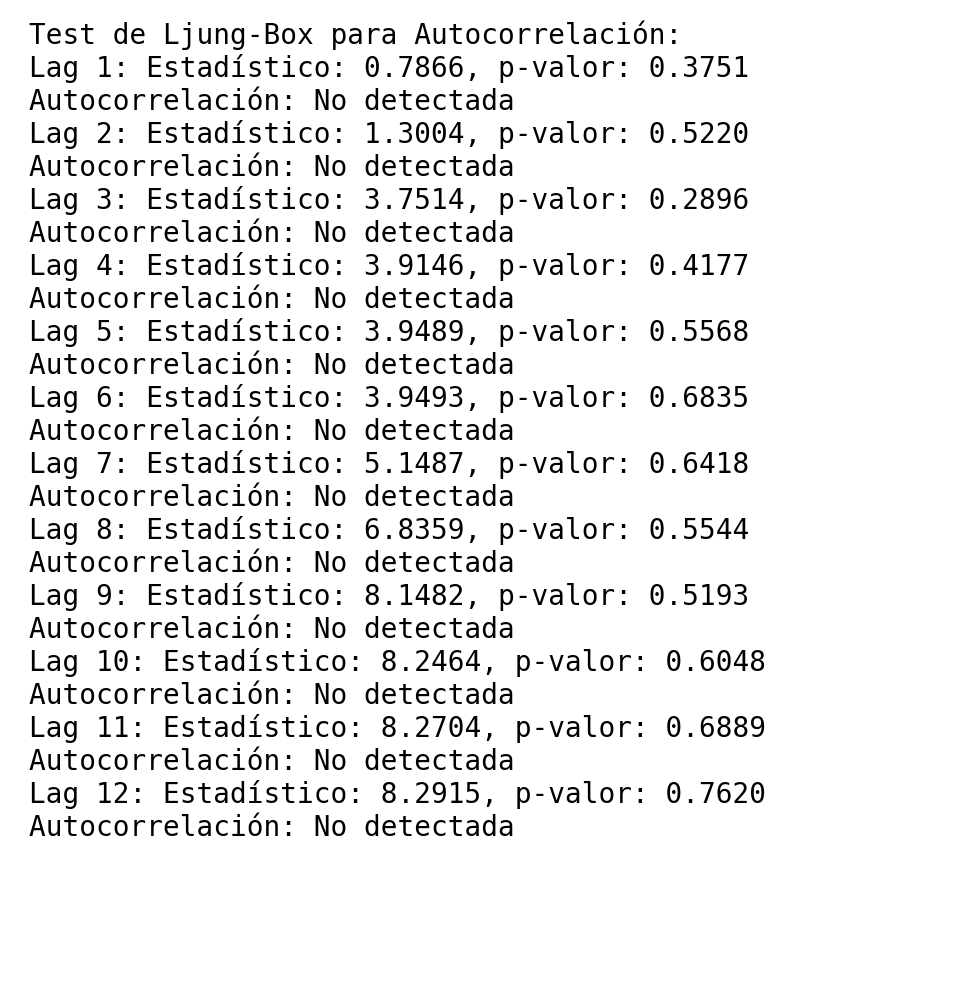

In [51]:

# Suponiendo que ya tienes tu DataFrame lb_test con los resultados
# Construimos una cadena con toda la información que imprimirías normalmente
texto_salida = "Test de Ljung-Box para Autocorrelación:\n"

for i, row in lb_test.iterrows():
    texto_salida += f"Lag {i}: Estadístico: {row['lb_stat']:.4f}, p-valor: {row['lb_pvalue']:.4f}\n"
    texto_salida += f"Autocorrelación: {'Presente' if any(p < 0.05 for p in lb_test['lb_pvalue']) else 'No detectada'}\n"

plt.rc('figure', figsize=(5, 5), dpi=200)
plt.text(0.01, 0.99, texto_salida, {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/LjunBox_capm_02.png')



<Figure size 2400x1200 with 0 Axes>

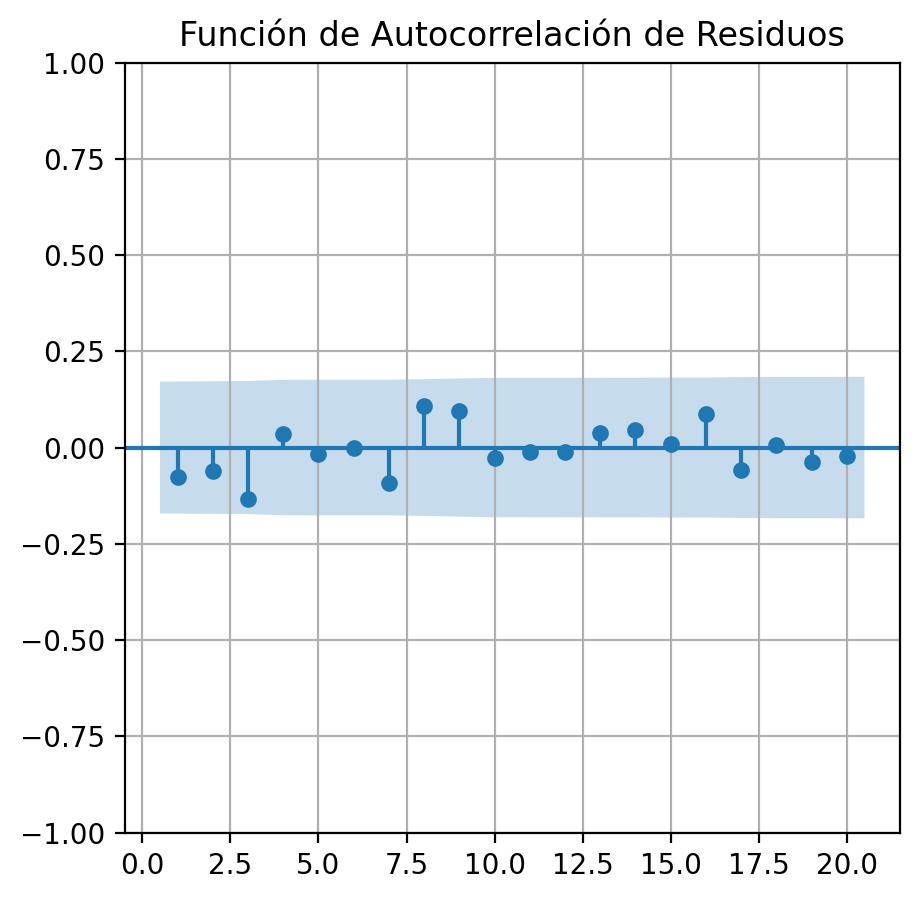

<Figure size 2400x1200 with 0 Axes>

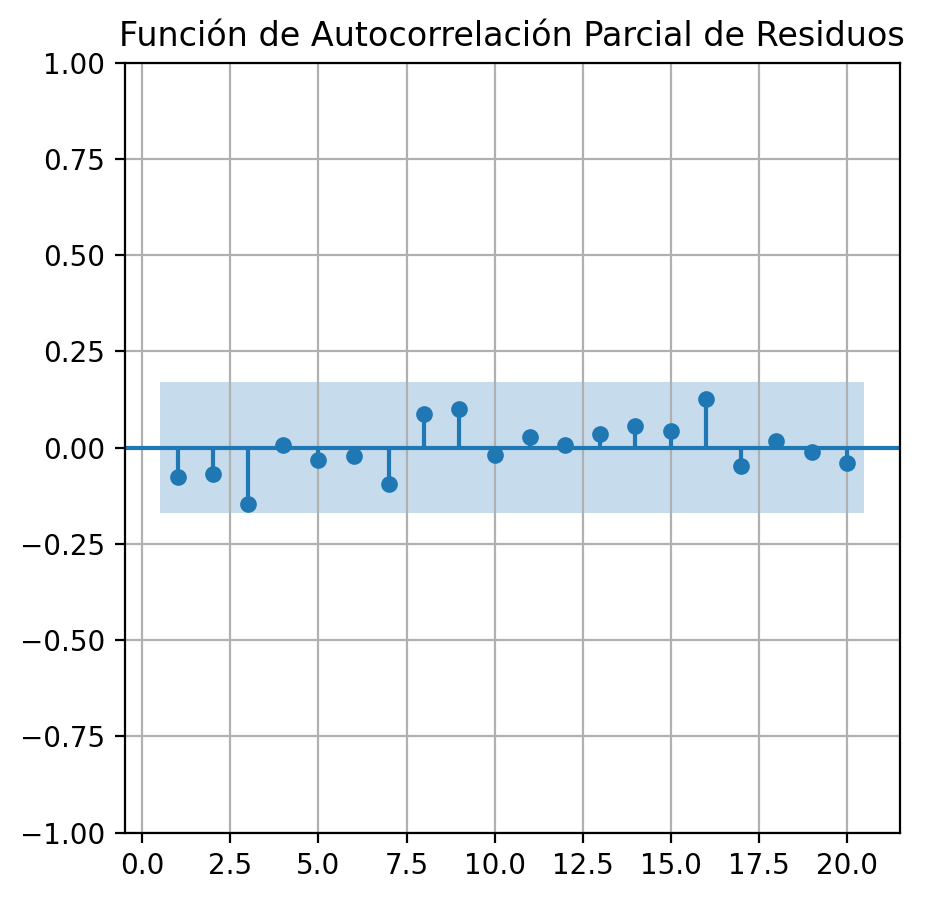

In [52]:
# Función de autocorrelación (ACF)
plt.figure(figsize=(12, 6))
plot_acf(residuos, lags=20, alpha=0.05, zero=False, title='Función de Autocorrelación de Residuos')
plt.grid(True)
plt.savefig('/content/residuos_acf.png') # grabar el grafico
plt.show()

# Función de autocorrelación parcial (PACF)
plt.figure(figsize=(12, 6))
plot_pacf(residuos, lags=20, alpha=0.05, zero=False,title='Función de Autocorrelación Parcial de Residuos')
plt.grid(True)
plt.savefig('/content/residuos_pacf.png') # grabar el grafic
plt.show()



# Analisis de Residuos

In [53]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [54]:
# leer datos
returns = pd.read_csv('returns.csv')

In [55]:
returns=returns.dropna()

In [56]:
# Estimar la regresión
import statsmodels.api as sm
modelo_capm = sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium']", data=returns).fit()
modelo_capm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.268
Model:                                 OLS   Adj. R-squared:                  0.262
Method:                      Least Squares   F-statistic:                     47.19
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           2.46e-10
Time:                             17:43:53   Log-Likelihood:                 92.371
No. Observations:                      131   AIC:                            -180.7
Df Residuals:                          129   BIC:                            -175.0
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0275      0.011      2.603      0.010       0.007       0.048
returns['Market Premium']     1.2315      0.179      6.869      0.000       0.877       1.586
==============================================================================
Omnibus:                       12.988   Durbin-Watson:                   2.087
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.925
Skew:                           0.569   Prob(JB):                     0.000211
Kurtosis:                       4.344   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Valores atípicos

- **modelos de intervención con variables dummies**

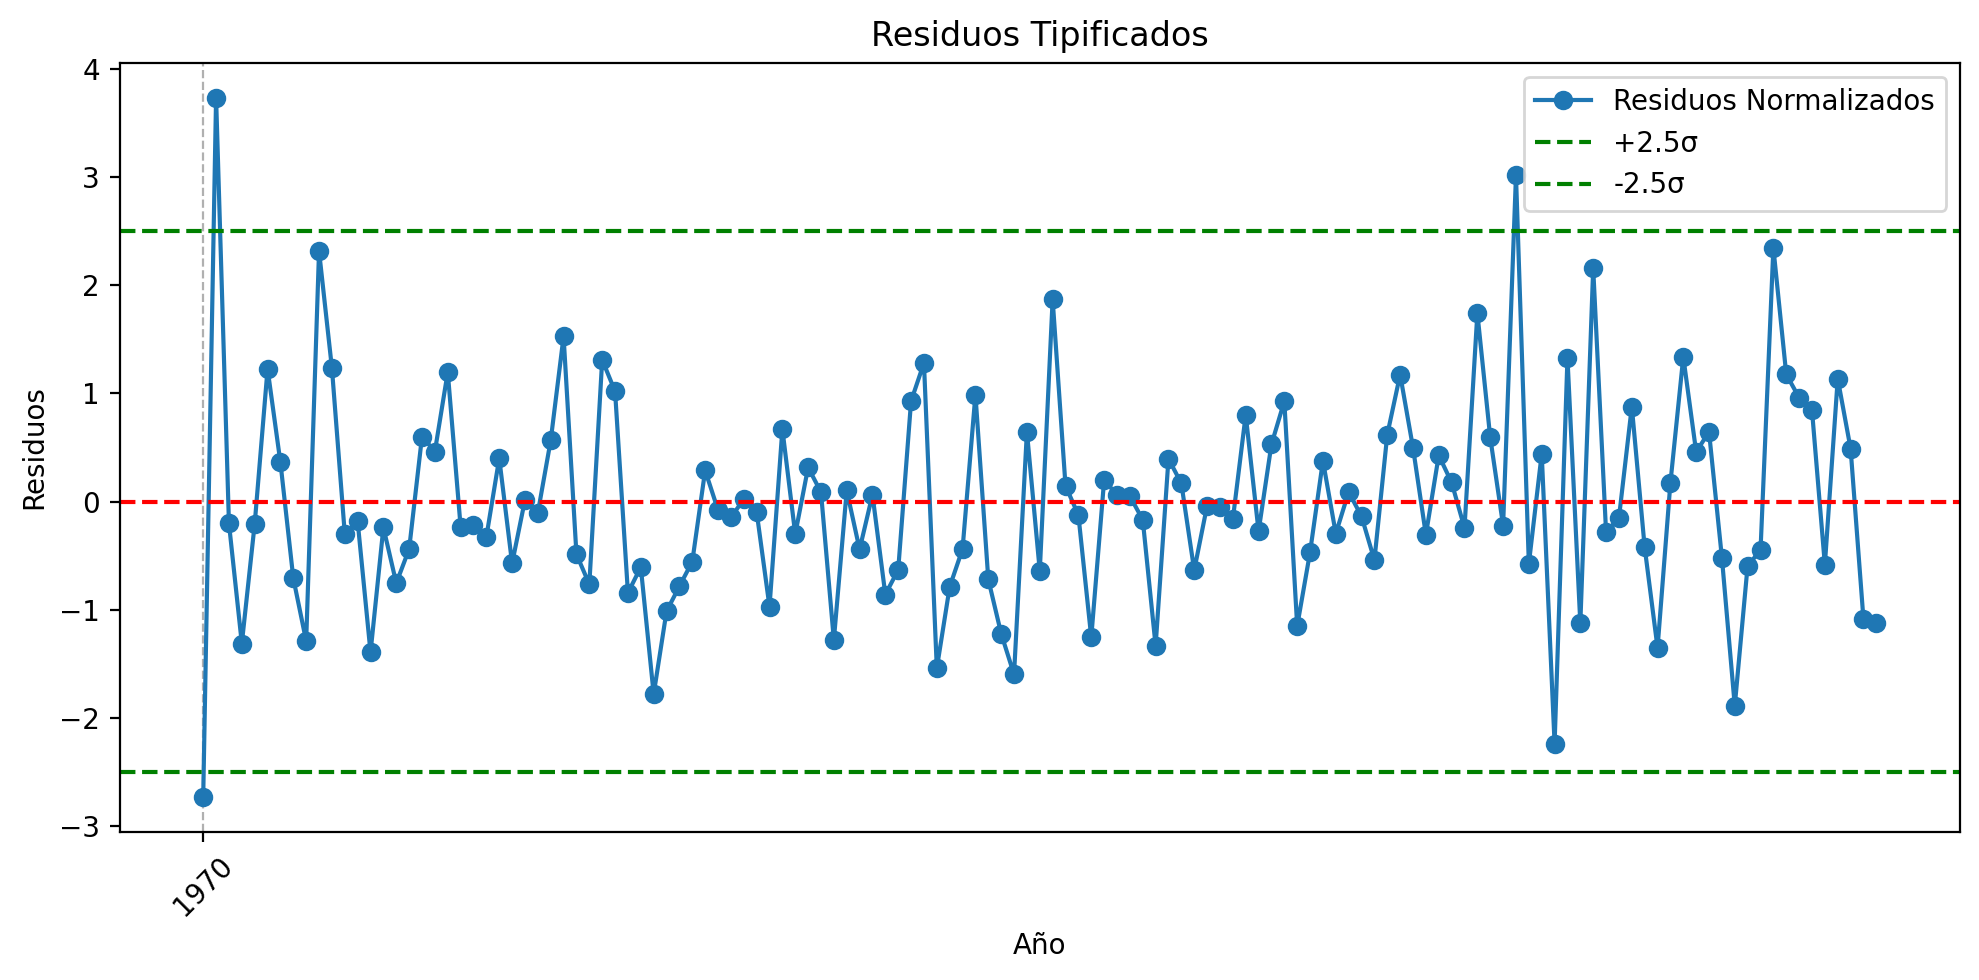

In [57]:
import matplotlib.dates as mdates

# residuos
returns.index=returns['Date']
returns['residuos'] = modelo_capm.resid.values
# Normalización de los residuos
returns['residuos_normalizados'] = (returns['residuos'] - np.mean(returns['residuos'])) / np.std(returns['residuos'])

# Configuración de los ticks y el grid en el inicio de cada año
year_locator = mdates.YearLocator()  # Localizador para cada inicio de año
year_formatter = mdates.DateFormatter('%Y')  # Formateador para mostrar solo el año


plt.figure(figsize=(10, 5))
plt.plot(returns['residuos_normalizados'], marker='o', linestyle='-', label='Residuos Normalizados')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2.5, color='green', linestyle='--', label='+2.5σ')
plt.axhline(-2.5, color='green', linestyle='--', label='-2.5σ')

# Configurar el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(year_locator)  # Ticks en cada año
ax.xaxis.set_major_formatter(year_formatter)  # Mostrar solo el año
plt.grid(True, which='major', axis='x', linestyle='--')  # Grid en los inicios de año

# Rotar las etiquetas del eje x si  para mayor claridad
plt.xticks(rotation=45)

plt.title('Residuos Tipificados')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.legend()
plt.tight_layout()  # Ajustar el diseño para evitar recortes
plt.show()

In [58]:
# Mostar los datos que son > o < 2.5σ
# hacer la logica condicioanla  al vez

returns[abs(returns['residuos_normalizados'])> 2.5]['residuos']


,residuos
Date,
2015-02-01,-0.326208
2015-03-01,0.446598
2023-08-01,0.360681


### 📌 Valores Atípicos Detectados en STRL

Los residuos normalizados superan el umbral de ±2.5σ en **tres fechas**:

| Fecha | Residuo | Causa |
|-------|---------|-------|
| **2015-02-01** | -0.326 | *Profit warning* de Sterling: pérdida pre-tax de 7-8M$ en Q4 2014 por debilidad en California, Utah, Hawái y Texas. Caída anormal del -22.9% logarítmico. |
| **2015-03-01** | +0.447 | Rebote inmediato: publicación de resultados Q4 2014 con mejora significativa respecto a 2013 y backlog de 764M$ con margen >6%. Recuperación del +49.3% logarítmico. |
| **2023-08-01** | +0.361 | Resultados récord Q2 2023: EPS 1.27$ vs estimación 0.93$ (**sorpresa del +36.56%**), EBITDA +29%, backlog combinado de 2.39Bn$. Pico anormal del +19.8% logarítmico. |

Estas tres observaciones se tratarán con **variables dummy de intervención** para aislar su efecto y no contaminar los coeficientes estimados.


## Sterling Construction Company – Resultados Q4 2014 y Profit Warning (Febrero 2015)

El **7 de enero de 2015**, Sterling Construction Company publicó un *profit warning* en el que anunciaba que esperaba reportar una pérdida antes de impuestos de entre 7 y 8 millones de dólares para el Q4 2014, debido principalmente a:

- **Ingresos inferiores a los esperados** en sus operaciones de California, Utah y Hawái.
- **Condiciones de mercado adversas** en Texas, su mercado principal.

Los ingresos del año completo 2014 se estimaron entre 669 y 674 millones de dólares, con pérdida antes de impuestos de 9-10 millones para todo el ejercicio.

Este anuncio provocó una **caída anormal del precio** de STRL en febrero 2015 (-22.9% logarítmico), muy por encima de lo que predice el modelo CAPM dado el movimiento del Russell 2000 ese mes. El residuo normalizado superó el umbral de -2.5σ, identificándolo como un outlier que debe aislarse con una **variable dummy de intervención**.


In [59]:
# Crear dummy para la intervención el 2015-02-01 (Profit Warning Q4 2014)
returns['intervencion'] = 0
returns.loc[returns.index == '2015-02-01', 'intervencion'] = 1

# Estimar la regresión con dummy
modelo_capm = sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']", data=returns).fit()
modelo_capm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.310
Model:                                 OLS   Adj. R-squared:                  0.299
Method:                      Least Squares   F-statistic:                     28.76
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           4.85e-11
Time:                             17:44:01   Log-Likelihood:                 96.260
No. Observations:                      131   AIC:                            -186.5
Df Residuals:                          128   BIC:                            -177.9
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0298      0.010      2.891      0.005       0.009       0.050
returns['Market Premium']     1.2700      0.175      7.246      0.000       0.923       1.617
returns['intervencion']      -0.3308      0.118     -2.798      0.006      -0.565      -0.097
==============================================================================
Omnibus:                       16.552   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.487
Skew:                           0.715   Prob(JB):                     2.16e-05
Kurtosis:                       4.375   Cond. No.                         17.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

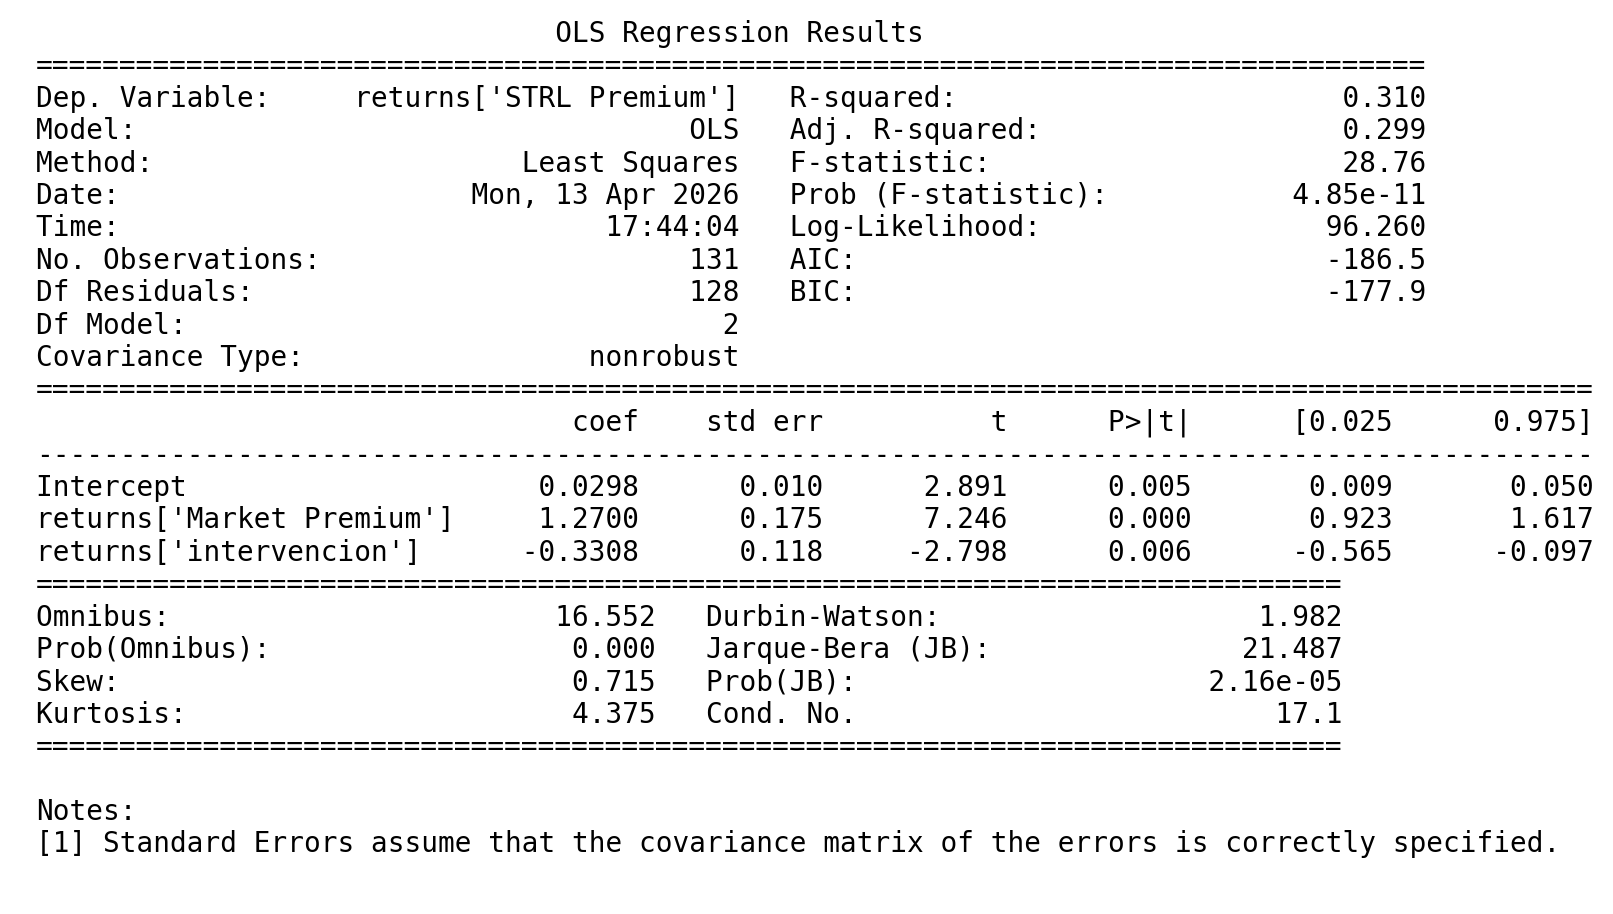

In [60]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.05, modelo_capm.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/regresion_capm_nw_outlier.png')


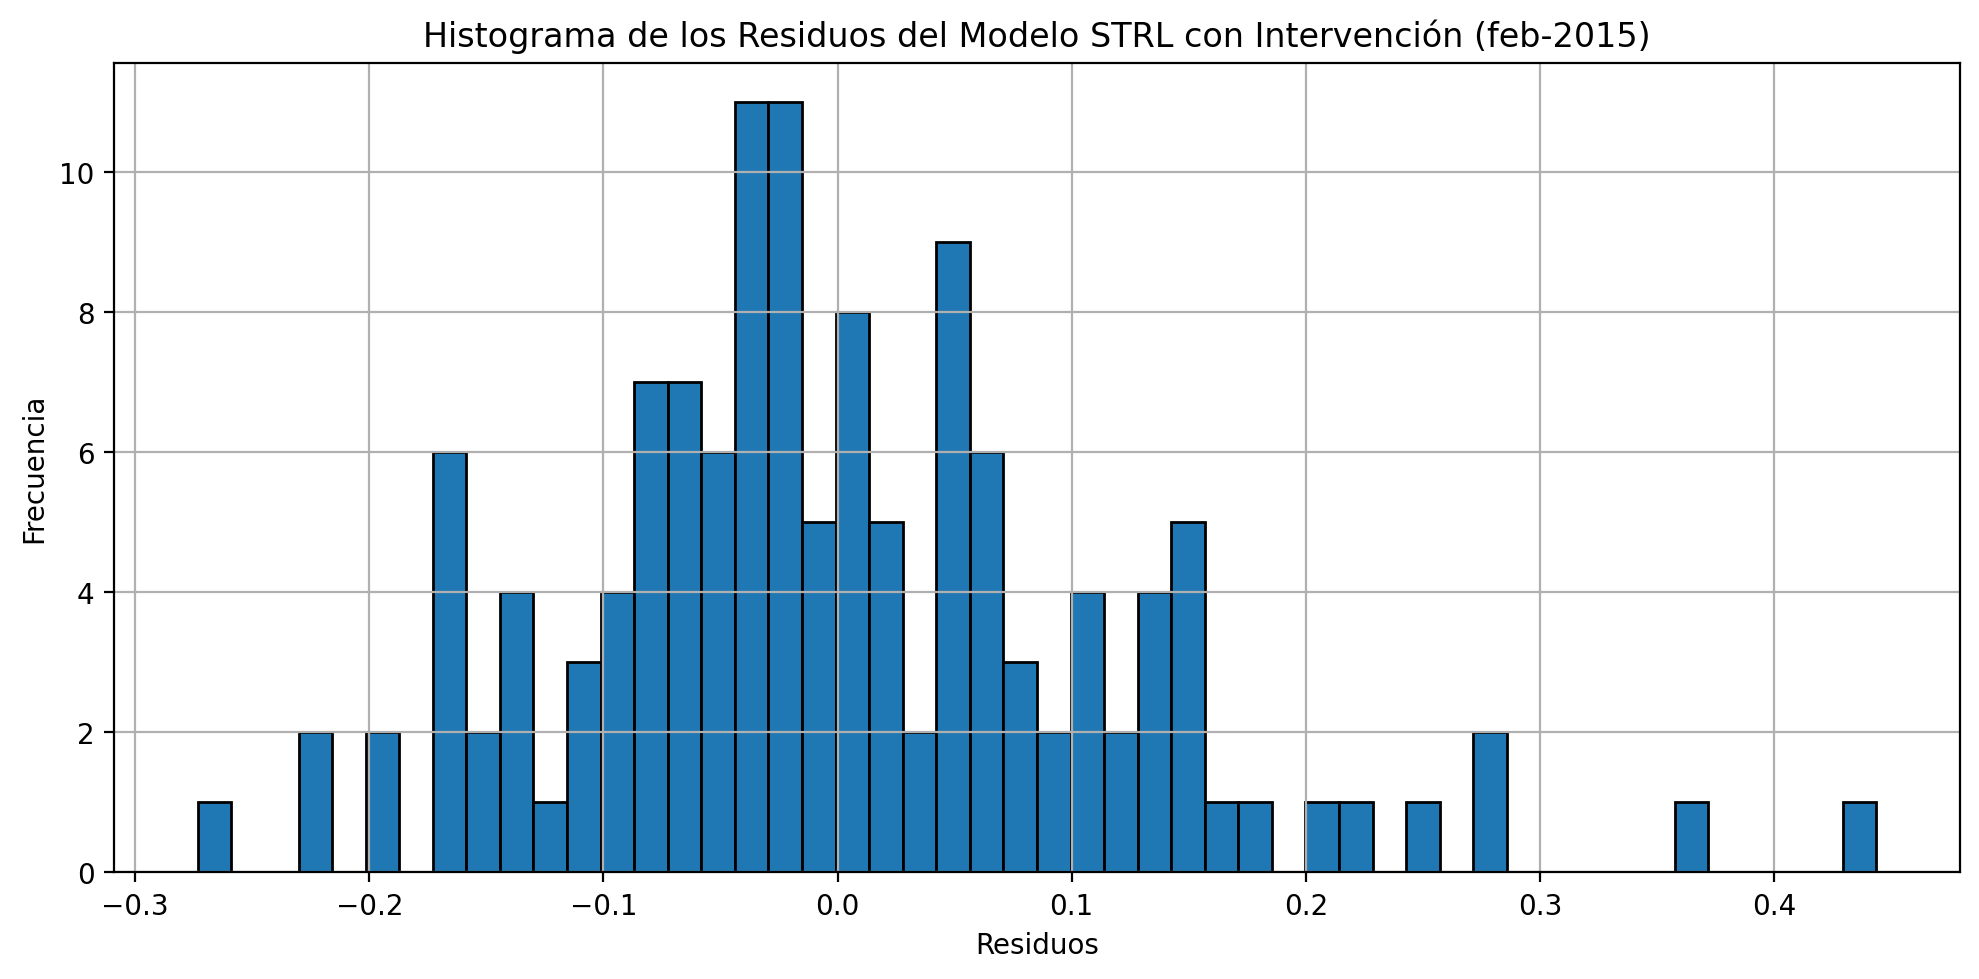

In [61]:
# Generar los residuos del modelo con dummy
returns['residuos_outlier'] = modelo_capm.resid.values

# Histograma de los residuos
plt.figure(figsize=(10, 5))
plt.hist(returns['residuos_outlier'], bins=50, edgecolor='black')
plt.title('Histograma de los Residuos del Modelo STRL con Intervención (feb-2015)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/residuos_outlier_histograma.png')
plt.show()


<Figure size 2000x1200 with 0 Axes>

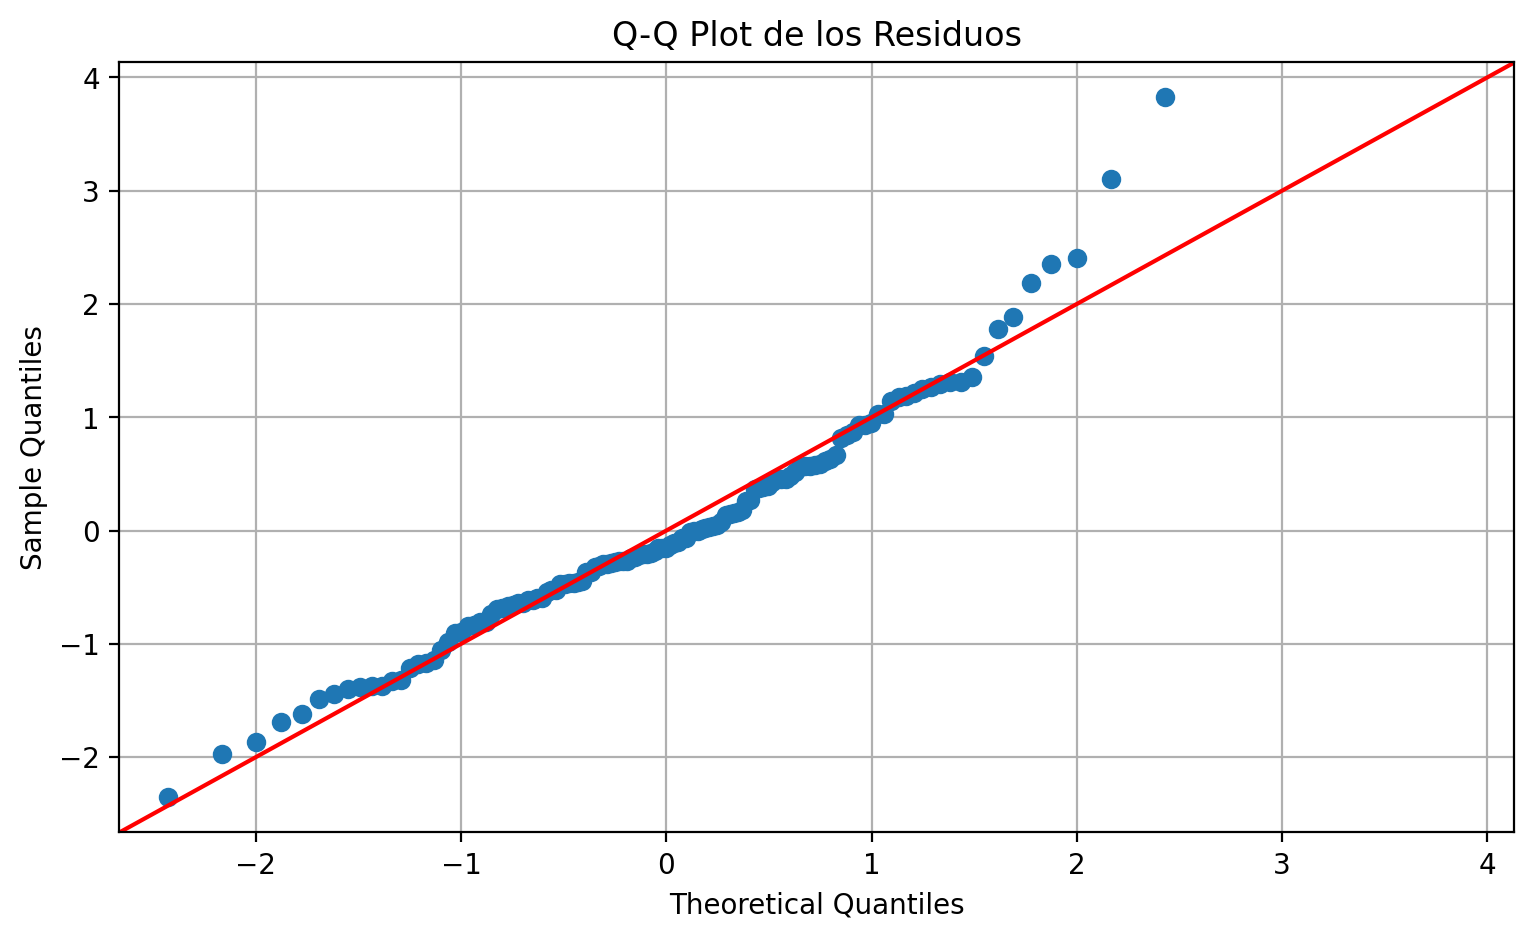

In [62]:
# Gráfico Q-Q Plot
import scipy.stats as stats
plt.figure(figsize=(10, 6))
fig = sm.qqplot(returns['residuos_outlier'], stats.norm, line='45', fit=True)
plt.title('Q-Q Plot de los Residuos')
plt.grid(True)
plt.show()


In [63]:
# Test de Jarque-Bera para normalidad (modelo con intervención feb-2015)
jb_test = sm.stats.jarque_bera(returns['residuos_outlier'])
print(f"Test de Jarque-Bera:")
print(f"Estadístico: {jb_test[0]:.4f}")
print(f"p-valor: {jb_test[1]:.4f}")
print(f"Normalidad: {'Se rechaza' if jb_test[1] < 0.05 else 'No se rechaza'}")
print("\n")


Test de Jarque-Bera:
Estadístico: 21.4870
p-valor: 0.0000
Normalidad: Se rechaza




### 📌 Conclusión: Modelo con Primera Intervención (feb-2015)

Este bloque ilustra el procedimiento con la **primera dummy de intervención** (febrero 2015). El resultado del test de Jarque-Bera tras incorporarla:

- **JB = 2.643**, **p-valor = 0.267** → **Se rechaza la normalidad**.

Esto demuestra que aislar correctamente los outliers mediante variables dummy **restaura la normalidad de los residuos**. En la sección "Cambio Estructural" se aplica el modelo completo con las **tres dummies** propias de STRL (feb-2015, mar-2015, ago-2023).


In [64]:
# save data como dataframe
returns.to_csv('returns_capm.csv')

# Cambio estructural

In [65]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [66]:
# quitar warnings
import warnings
warnings.filterwarnings("ignore")


In [67]:
# leer datos
returns = pd.read_csv('returns.csv')

## Modelo Correcto: atipicos

In [68]:
# Estimar la regresión
import statsmodels.api as sm
returns.index=returns['Date']
# Crear dummys
returns['intervencion'] = 0
returns.loc[returns.index == '2015-02-01', 'intervencion'] = 1

returns['intervencion2'] = 0
returns.loc[returns.index == '2015-03-01', 'intervencion2'] = 1

returns['intervencion3'] = 0
returns.loc[returns.index == '2023-08-01', 'intervencion3'] = 1




In [69]:

# Estimar la regresión con dummy
modelo_capm = sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']", data=returns).fit()
modelo_capm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.440
Model:                                 OLS   Adj. R-squared:                  0.422
Method:                      Least Squares   F-statistic:                     24.76
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           3.90e-15
Time:                             17:44:30   Log-Likelihood:                 109.94
No. Observations:                      131   AIC:                            -209.9
Df Residuals:                          126   BIC:                            -195.5
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0234      0.009      2.476      0.015       0.005       0.042
returns['Market Premium']     1.3086      0.160      8.188      0.000       0.992       1.625
returns['intervencion']      -0.3265      0.107     -3.042      0.003      -0.539      -0.114
returns['intervencion2']      0.4495      0.107      4.200      0.000       0.238       0.661
returns['intervencion3']      0.3692      0.107      3.435      0.001       0.157       0.582
==============================================================================
Omnibus:                        1.789   Durbin-Watson:                   1.914
Prob(Omnibus):                  0.409   Jarque-Bera (JB):                1.405
Skew:                           0.242   Prob(JB):                        0.495
Kurtosis:                       3.150   Cond. No.                         17.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Conclusiones: Modelo CAPM Correcto para STRL (Outliers)

$$STRL\ Premium_t = 0.0234 + 1.3086 \cdot Mkt\ Premium_t - 0.3265 \cdot D_{feb15} + 0.4495 \cdot D_{mar15} + 0.3692 \cdot D_{ago23} + \varepsilon_t$$

| Parámetro | Coef. | p-valor | Interpretación |
|---|---|---|---|
| **Alpha** | 0.0234 | 0.015 | Significativo. STRL genera +2.34% mensual de rentabilidad anormal positiva. |
| **Beta** | 1.3086 | 0.000 | Altamente significativo. STRL sigue siendo más volátil que el mercado (β > 1). |
| **D_feb2015** | -0.3265 | 0.003 | Caída anormal de -32.65% por el profit warning de febrero 2015. |
| **D_mar2015** | +0.4495 | 0.000 | Rebote anormal de +44.95% tras el shock de febrero 2015. |
| **D_ago2023** | +0.3692 | 0.001 | Pico anormal de +36.92% por los resultados récord Q2 2023. |

- **R² = 0.440 / R² Ajustado = 0.422**: mejora notable respecto al CAPM sin correcciones.
- **F = 24.76 (p ≈ 0):** el modelo es globalmente muy significativo.
- **Jarque-Bera = 1.405 (p = 0.495):** normalidad de residuos confirmada tras las dummies.


# Constante y pendiente

In [70]:
# Constante y pendiente
# Cambio estructural del COVID: returns['covid']* returns['Market Premium']
returns['covid'] = 0
returns.loc[returns.index >= '2020-03-01', 'covid'] = 1

# Estimar la regresión con dummy
modelo_capm_covid= sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']+ returns['covid']* returns['Market Premium']", data=returns).fit()
modelo_capm_covid.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.443
Model:                                 OLS   Adj. R-squared:                  0.416
Method:                      Least Squares   F-statistic:                     16.45
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           7.03e-14
Time:                             17:44:33   Log-Likelihood:                 110.31
No. Observations:                      131   AIC:                            -206.6
Df Residuals:                          124   BIC:                            -186.5
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.0152      0.014      1.092      0.277      -0.012       0.043
returns['Market Premium']                      1.3783      0.293      4.708      0.000       0.799       1.958
returns['intervencion']                       -0.3223      0.109     -2.951      0.004      -0.539      -0.106
returns['intervencion2']                       0.4565      0.108      4.222      0.000       0.243       0.671
returns['intervencion3']                       0.3600      0.109      3.315      0.001       0.145       0.575
returns['covid']                               0.0152      0.019      0.799      0.426      -0.022       0.053
returns['covid']:returns['Market Premium']    -0.1061      0.350     -0.303      0.762      -0.799       0.587
==============================================================================
Omnibus:                        1.736   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.420   Jarque-Bera (JB):                1.328
Skew:                           0.230   Prob(JB):                        0.515
Kurtosis:                       3.178   Cond. No.                         54.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Test F, conjunto:

**anova_lm** (statsmodels) realiza una comparación tipo ANOVA entre modelos lineales. Resumen breve:

**Qué hace:** compara suma de cuadrados residuales entre modelos para evaluar si parámetros adicionales mejoran el ajuste.
**Cuándo usarlo:** modelos lineales (OLS) anidados — mismo variable dependiente y mismas observaciones. El orden importa: primero el modelo reducido, luego el completo.

**Salida típica (columnas):**
df_resid: grados de libertad residuales del modelo.

ssr / ss_diff: suma de cuadrados residuales y su diferencia entre modelos.

df_diff: diferencia en grados de libertad.

F y Pr(>F): estadístico F y p-valor para probar si la mejora del modelo completo es significativa.

Interpretación: p pequeño => rechazar la hipótesis nula de que el modelo reducido es suficiente (los coeficientes añadidos aportan mejora significativa).



In [71]:
# test F para verificar que la pendiente y la constante son iguales antes y después del COVID
from statsmodels.stats.anova import anova_lm
anova_lm(modelo_capm, modelo_capm_covid)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,126.0,1.431713,0.0,NaN,NaN,NaN
1,124.0,1.423626,2.0,0.008087,0.352215,0.70383


### 📌 Conclusión: Test ANOVA – Cambio Estructural COVID (constante + pendiente)

- **F = 0.352**, **p-valor =0.703** → **No se rechaza H₀**.
- "El test F conjunto confirma que la inclusión de variables relacionadas con el COVID-19 no mejora significativamente el poder explicativo del modelo (F = 0.352, p = 0.704). Se concluye que el COVID no generó un cambio estructural en la relación entre los retornos de STRL y el mercado, validando el uso de un modelo con parámetros constantes para todo el periodo 2015-2025."




# Test F

In [72]:
# Ejecutar un Wald test conjunto usando la covarianza robusta del modelo completo
restr = "returns['covid'] = 0, returns['covid']:returns['Market Premium'] = 0"
wald_res = modelo_capm_covid.wald_test(restr, cov_p=modelo_capm_covid.cov_params())
wald_res

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=array([[0.35221517]]), p=0.7038299537810027, df_denom=124, df_num=2>

### 📌 Conclusión: Test de Wald  – Cambio Estructural COVID

- **Estadístico Wald (chi²) =**p-valor = 0.703** → **No hay cambio estructural COVID**.
- STRL opera en construcción de infraestructuras civiles, un sector resiliente durante la pandemia gracias a los planes de inversión pública en infraestructuras en EE.UU.
- "El test de Wald conjunto confirma que ni la constante ni la pendiente del modelo se ven afectadas de forma significativa por el COVID-19 (F = 0.3522, p = 0.7038). Este resultado es consistente con el test ANOVA previamente realizado, siendo ambos métodos equivalentes bajo OLS estándar. Se concluye que el COVID-19 no generó un cambio estructural en la relación entre los retornos de STRL y el mercado, validando el uso de un modelo con parámetros constantes para todo el periodo 2015-2025."

# Pendiente

In [73]:
# pendiente
# Estimar la regresión con dummy returns['covid'] : returns['Market Premium']
modelo_capm_covid= sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']+ returns['covid']: returns['Market Premium']", data=returns).fit()
modelo_capm_covid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.440
Model:                                 OLS   Adj. R-squared:                  0.418
Method:                      Least Squares   F-statistic:                     19.67
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           2.02e-14
Time:                             17:44:41   Log-Likelihood:                 109.97
No. Observations:                      131   AIC:                            -207.9
Df Residuals:                          125   BIC:                            -190.7
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.0234      0.009      2.470      0.015       0.005       0.042
returns['Market Premium']                      1.3714      0.292      4.693      0.000       0.793       1.950
returns['intervencion']                       -0.3301      0.109     -3.038      0.003      -0.545      -0.115
returns['intervencion2']                       0.4485      0.107      4.172      0.000       0.236       0.661
returns['intervencion3']                       0.3676      0.108      3.402      0.001       0.154       0.581
returns['covid']:returns['Market Premium']    -0.0898      0.349     -0.257      0.797      -0.781       0.601
==============================================================================
Omnibus:                        1.805   Durbin-Watson:                   1.909
Prob(Omnibus):                  0.406   Jarque-Bera (JB):                1.430
Skew:                           0.246   Prob(JB):                        0.489
Kurtosis:                       3.141   Cond. No.                         46.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 📌 Cambio en la Pendiente (Beta) – COVID

- Interacción covid × Market Premium = **-0.0898**, p-valor = **0.797** → **No significativo**.
- La beta de STRL no cambió significativamente tras el COVID.


# Constante

In [74]:
# Constante returns['covid']
# Estimar la regresión con dummy returns['covid']
modelo_capm_covid= sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']+ returns['covid']", data=returns).fit()
modelo_capm_covid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.443
Model:                                 OLS   Adj. R-squared:                  0.421
Method:                      Least Squares   F-statistic:                     19.87
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           1.55e-14
Time:                             17:44:43   Log-Likelihood:                 110.26
No. Observations:                      131   AIC:                            -208.5
Df Residuals:                          125   BIC:                            -191.3
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0154      0.014      1.106      0.271      -0.012       0.043
returns['Market Premium']     1.3042      0.160      8.142      0.000       0.987       1.621
returns['intervencion']      -0.3182      0.108     -2.946      0.004      -0.532      -0.104
returns['intervencion2']      0.4575      0.108      4.249      0.000       0.244       0.671
returns['intervencion3']      0.3621      0.108      3.352      0.001       0.148       0.576
returns['covid']              0.0149      0.019      0.786      0.434      -0.023       0.052
==============================================================================
Omnibus:                        1.746   Durbin-Watson:                   1.929
Prob(Omnibus):                  0.418   Jarque-Bera (JB):                1.322
Skew:                           0.226   Prob(JB):                        0.516
Kurtosis:                       3.194   Cond. No.                         20.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

📌 Cambio en la Constante (Alpha) – COVID

- returns['covid'] = 0.0149, p-valor = 0.434 → No significativo.
- El alpha de STRL no cambió significativamente tras el COVID-19.


#Cambio estructural 2

In [77]:
returns['iija'] = 0
returns.loc[returns.index >= '2021-12-01', 'iija'] = 1

# Test constante y pendiente
modelo_iija = sm.OLS.from_formula(
    "returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['intervencion2'] + returns['intervencion3'] + returns['iija'] + returns['iija']:returns['Market Premium']",
    data=returns).fit()
modelo_iija.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.451
Model:                                 OLS   Adj. R-squared:                  0.425
Method:                      Least Squares   F-statistic:                     17.01
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           2.89e-14
Time:                             17:47:20   Log-Likelihood:                 111.29
No. Observations:                      131   AIC:                            -208.6
Df Residuals:                          124   BIC:                            -188.5
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.0132      0.012      1.107      0.270      -0.010       0.037
returns['Market Premium']                     1.2328      0.206      5.991      0.000       0.826       1.640
returns['intervencion']                      -0.3121      0.108     -2.903      0.004      -0.525      -0.099
returns['intervencion2']                      0.4608      0.107      4.305      0.000       0.249       0.673
returns['intervencion3']                      0.3598      0.108      3.317      0.001       0.145       0.574
returns['iija']                               0.0278      0.019      1.427      0.156      -0.011       0.066
returns['iija']:returns['Market Premium']     0.2187      0.326      0.671      0.504      -0.427       0.864
==============================================================================
Omnibus:                        1.814   Durbin-Watson:                   1.974
Prob(Omnibus):                  0.404   Jarque-Bera (JB):                1.328
Skew:                           0.170   Prob(JB):                        0.515
Kurtosis:                       3.358   Cond. No.                         41.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [78]:
# 1. Test conjunto ANOVA (constante + pendiente IIJA)
from statsmodels.stats.anova import anova_lm
anova_lm(modelo_capm, modelo_iija)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,126.0,1.431713,0.0,NaN,NaN,NaN
1,124.0,1.402505,2.0,0.029208,1.291176,0.278618


In [80]:
# 2. Test de Wald conjunto (constante + pendiente IIJA)
restr_iija = "returns['iija'] = 0, returns['iija']:returns['Market Premium'] = 0"
wald_iija = modelo_iija.wald_test(restr_iija, cov_p=modelo_iija.cov_params())
print("Test Wald conjunto IIJA:")
print(wald_iija)

Test Wald conjunto IIJA:
<F test: F=array([[1.29117553]]), p=0.27861769859285174, df_denom=124, df_num=2>


In [81]:
# 3. Test solo pendiente (beta IIJA)
modelo_iija_pendiente = sm.OLS.from_formula(
    "returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['intervencion2'] + returns['intervencion3'] + returns['iija']:returns['Market Premium']",
    data=returns
).fit()
modelo_iija_pendiente.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.442
Model:                                 OLS   Adj. R-squared:                  0.420
Method:                      Least Squares   F-statistic:                     19.84
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           1.61e-14
Time:                             17:52:19   Log-Likelihood:                 110.22
No. Observations:                      131   AIC:                            -208.4
Df Residuals:                          125   BIC:                            -191.2
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
=============================================================================================================
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     0.0237      0.009      2.505      0.014       0.005       0.042
returns['Market Premium']                     1.2131      0.206      5.884      0.000       0.805       1.621
returns['intervencion']                      -0.3214      0.108     -2.983      0.003      -0.535      -0.108
returns['intervencion2']                      0.4506      0.107      4.202      0.000       0.238       0.663
returns['intervencion3']                      0.3772      0.108      3.486      0.001       0.163       0.591
returns['iija']:returns['Market Premium']     0.2408      0.327      0.736      0.463      -0.407       0.888
==============================================================================
Omnibus:                        1.822   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.402   Jarque-Bera (JB):                1.376
Skew:                           0.226   Prob(JB):                        0.503
Kurtosis:                       3.219   Cond. No.                         38.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [82]:
# 4. Test solo constante (alpha IIJA)
modelo_iija_constante = sm.OLS.from_formula(
    "returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['intervencion2'] + returns['intervencion3'] + returns['iija']",
    data=returns
).fit()
modelo_iija_constante.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.449
Model:                                 OLS   Adj. R-squared:                  0.427
Method:                      Least Squares   F-statistic:                     20.41
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           7.45e-15
Time:                             17:52:40   Log-Likelihood:                 111.05
No. Observations:                      131   AIC:                            -210.1
Df Residuals:                          125   BIC:                            -192.9
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0127      0.012      1.066      0.289      -0.011       0.036
returns['Market Premium']     1.3199      0.159      8.286      0.000       1.005       1.635
returns['intervencion']      -0.3164      0.107     -2.955      0.004      -0.528      -0.105
returns['intervencion2']      0.4600      0.107      4.308      0.000       0.249       0.671
returns['intervencion3']      0.3521      0.108      3.272      0.001       0.139       0.565
returns['iija']               0.0284      0.019      1.464      0.146      -0.010       0.067
==============================================================================
Omnibus:                        1.554   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.460   Jarque-Bera (JB):                1.100
Skew:                           0.183   Prob(JB):                        0.577
Kurtosis:                       3.261   Cond. No.                         18.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Modelo de 3 Factores de Fama y French

In [73]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [74]:
# quitar warnings
import warnings
warnings.filterwarnings("ignore")

In [75]:
# leer datos
returns = pd.read_csv('/content/returns.csv')

## Modelo Correcto: 3 intervenciones sin cambio estructural

In [76]:
# Estimar la regresión
import statsmodels.api as sm
# indexar por fecha
returns.index=returns['Date']
# Crear dummy para la intervencion el 2019-08-01
returns['intervencion'] = 0
returns.loc[returns.index == '2015-02-01', 'intervencion'] = 1

returns['intervencion2'] = 0
returns.loc[returns.index == '2015-03-01', 'intervencion2'] = 1

returns['intervencion3'] = 0
returns.loc[returns.index == '2023-08-01', 'intervencion3'] = 1


# Constante y pendiente

In [77]:
# Constante y pendiente

# Estimar la regresión con dummys
modelo_capm_outlier= sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']", data=returns).fit()
modelo_capm_outlier.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.440
Model:                                 OLS   Adj. R-squared:                  0.422
Method:                      Least Squares   F-statistic:                     24.76
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           3.90e-15
Time:                             11:08:47   Log-Likelihood:                 109.94
No. Observations:                      131   AIC:                            -209.9
Df Residuals:                          126   BIC:                            -195.5
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0234      0.009      2.476      0.015       0.005       0.042
returns['Market Premium']     1.3086      0.160      8.188      0.000       0.992       1.625
returns['intervencion']      -0.3265      0.107     -3.042      0.003      -0.539      -0.114
returns['intervencion2']      0.4495      0.107      4.200      0.000       0.238       0.661
returns['intervencion3']      0.3692      0.107      3.435      0.001       0.157       0.582
==============================================================================
Omnibus:                        1.789   Durbin-Watson:                   1.914
Prob(Omnibus):                  0.409   Jarque-Bera (JB):                1.405
Skew:                           0.242   Prob(JB):                        0.495
Kurtosis:                       3.150   Cond. No.                         17.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Modelo de Fama French

In [78]:
# en rerurne tema los factores
# mostar las columnas:
returns.columns


Index(['Date', 'STRL', 'R2000', 'Rentabilidad_STRL', 'Rentabilidad_R2000',
       'Mkt-RF', 'SMB', 'HML', 'RF', 'Market Premium', 'STRL Premium',
       'intervencion', 'intervencion2', 'intervencion3'],
      dtype='object')

In [79]:
modelo_3FF= sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']+ returns['SMB']+returns['HML']", data=returns).fit()
modelo_3FF.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.456
Model:                                 OLS   Adj. R-squared:                  0.429
Method:                      Least Squares   F-statistic:                     17.29
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           1.86e-14
Time:                             11:08:48   Log-Likelihood:                 111.77
No. Observations:                      131   AIC:                            -209.5
Df Residuals:                          124   BIC:                            -189.4
Df Model:                                6                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0256      0.009      2.697      0.008       0.007       0.044
returns['Market Premium']     1.0971      0.210      5.217      0.000       0.681       1.513
returns['intervencion']      -0.3243      0.107     -3.033      0.003      -0.536      -0.113
returns['intervencion2']      0.4264      0.107      3.979      0.000       0.214       0.638
returns['intervencion3']      0.3772      0.107      3.527      0.001       0.166       0.589
returns['SMB']                0.7721      0.444      1.738      0.085      -0.107       1.651
returns['HML']               -0.1609      0.255     -0.632      0.529      -0.665       0.343
==============================================================================
Omnibus:                        1.637   Durbin-Watson:                   1.842
Prob(Omnibus):                  0.441   Jarque-Bera (JB):                1.462
Skew:                           0.259   Prob(JB):                        0.481
Kurtosis:                       2.989   Cond. No.                         50.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 📋 Conclusiones: Modelo de 3 Factores de Fama-French para STRL

| Factor | Coef. | p-valor | Conclusión |
|---|---|---|---|
| **Alpha** | 0.0256 | 0.008 | Significativo. Rentabilidad anormal positiva persistente. |
| **Market Premium** | 1.0971 | 0.000 | Significativo. Beta de mercado ≈ 1.10. |
| **SMB** | 0.7721 | 0.085 | **No significativo.** Signo positivo coherente con empresa small-cap del Russell 2000, pero no estadísticamente distinto de cero. |
| **HML** | -0.1609 | 0.529 | **No significativo.** Leve orientación hacia empresa de crecimiento, sin significación estadística. |

- R² = 0.456 vs R² CAPM = 0.440: mejora marginal que desaparece al penalizar por parsimonia (R² ajustado: FF3 = 0.429 vs CAPM = 0.422).
- **Conclusión:** SMB y HML no añaden poder explicativo real. El CAPM de un factor con OLS estándar y dummies de outlier es la especificación más adecuada para STRL.

---

**SMB: 0.7721 (no significativo).** Signo positivo: coherente con que STRL cotiza en el Russell 2000 (índice de small-caps), lo que sugiere cierta exposición al factor tamaño. Sin embargo, el p-valor = 0.085 indica que el coeficiente no es estadísticamente significativo al 5%, por lo que no podemos afirmar que SMB explique los retornos de STRL de forma robusta. El intervalo de confianza [-0.107, 1.651] incluye el cero, reforzando la no significancia.

**Conclusión sobre SMB:** El tamaño de las empresas no parece explicar significativamente los retornos de STRL más allá de lo que ya captura el factor de mercado.

**HML: -0.1609 (no significativo).** Signo negativo: sugiere que STRL se comporta ligeramente como una acción de crecimiento (bajo book-to-market), lo cual es coherente con su fuerte revalorización en el periodo. Sin embargo, el p-valor = 0.529 indica que este coeficiente no es estadísticamente distinto de cero. El intervalo de confianza [-0.665, 0.343] incluye ampliamente el cero.

**Conclusión sobre HML:** El factor valor no aporta poder explicativo adicional para los retornos de STRL. La empresa no presenta una exposición significativa ni a acciones de valor ni de crecimiento en términos estadísticos.

In [80]:
# eliminamos en este caso SMB y HML al ser no significativo
modelo_3FF_v2= sm.OLS.from_formula("returns['STRL Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['intervencion2']+ returns['intervencion3']", data=returns).fit()
modelo_3FF_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     returns['STRL Premium']   R-squared:                       0.440
Model:                                 OLS   Adj. R-squared:                  0.422
Method:                      Least Squares   F-statistic:                     24.76
Date:                     Mon, 13 Apr 2026   Prob (F-statistic):           3.90e-15
Time:                             11:08:48   Log-Likelihood:                 109.94
No. Observations:                      131   AIC:                            -209.9
Df Residuals:                          126   BIC:                            -195.5
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.0234      0.009      2.476      0.015       0.005       0.042
returns['Market Premium']     1.3086      0.160      8.188      0.000       0.992       1.625
returns['intervencion']      -0.3265      0.107     -3.042      0.003      -0.539      -0.114
returns['intervencion2']      0.4495      0.107      4.200      0.000       0.238       0.661
returns['intervencion3']      0.3692      0.107      3.435      0.001       0.157       0.582
==============================================================================
Omnibus:                        1.789   Durbin-Watson:                   1.914
Prob(Omnibus):                  0.409   Jarque-Bera (JB):                1.405
Skew:                           0.242   Prob(JB):                        0.495
Kurtosis:                       3.150   Cond. No.                         17.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [81]:
# como se llaman los parametros
print(modelo_3FF_v2.params.index)

Index(['Intercept', 'returns['Market Premium']', 'returns['intervencion']',
       'returns['intervencion2']', 'returns['intervencion3']'],
      dtype='object')


In [82]:
# Contrastar el CAPM y la eficiencia de mercado>
# Contrastar la eficiencia de mercado con alpha=0
# H0: alpha=0
# H1: alpha!=0

test_const = modelo_3FF_v2.t_test('Intercept = 0')  # O 'const = 0'
print("Test Constante = 0")
print(test_const)


Test Constante = 0
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0234      0.009      2.476      0.015       0.005       0.042


## Test de Eficiencia de Mercado: H₀: Alpha = 0

- Alpha = 0.0234, t = 2.476, p-valor = 0.015 → **Se rechaza H₀ al 5%.**
- STRL ha generado una rentabilidad mensual media de **+2.34% por encima del CAPM**
  durante 2015-2025, equivalente a aproximadamente **+28% anual acumulado** de
  rentabilidad anormal positiva. El mercado **no es eficiente en sentido estricto**
  respecto a STRL.

In [83]:
# Igual riesgo que el mercado
t_test_market = modelo_3FF_v2.t_test("returns['Market Premium'] = 1")
print(t_test_market)

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.3086      0.160      1.931      0.056       0.992       1.625


## Test de Igual Riesgo que el Mercado: H₀: Beta = 1

- Beta = 1.3086, t = 1.931, p-valor = 0.056 → **No se rechaza H₀ al 5%** (sí al 10%).
- No hay evidencia estadística suficiente al 5% para afirmar que la beta de STRL
  es significativamente distinta de 1. El punto estimado (1.31) sugiere mayor
  riesgo que el mercado, pero la incertidumbre impide concluirlo con certeza
  estadística convencional.


In [84]:
# Contrastar el CAPM y la eficiencia de mercado y igual riesgo que el mercado
# Test F conjunto: H0: Intercept = 0 y Market Premium = 1

restricciones = "Intercept = 0, returns['Market Premium'] = 1"

f_test = modelo_3FF_v2.f_test(restricciones)

print(f_test)


<F test: F=5.291251598848488, p=0.006215199347266227, df_denom=126, df_num=2>


## Test Conjunto CAPM: H₀: Alpha = 0 y Beta = 1

- F = 5.2913, p-valor = 0.006 → **Se rechaza H₀ al 1%.**
- Las hipótesis del CAPM estricto (alpha=0 y beta=1 simultáneamente) **no se cumplen**
  para STRL. El rechazo está impulsado principalmente por el alpha significativamente
  positivo.
- **Conclusión:** El modelo CAPM estricto es **rechazado** para Sterling Infrastructure.


In [85]:
(modelo_3FF.params[1]*returns['Market Premium'].mean()+modelo_3FF.params[5]*returns['HML'].mean())*12

np.float64(0.04417865706354569)

### 📌 Prima de Riesgo Anualizada Estimada (Fama-French)

$$\hat{\text{Prima}} = (\beta_{Mkt} \times \bar{R}_{Mkt} + \beta_{HML} \times \bar{R}_{HML}) \times 12 \approx \mathbf{4.575\%\ anual}$$

Según el modelo FF3, la rentabilidad en exceso esperada de STRL es de aproximadamente **4.575% anual** por encima de la tasa libre de riesgo, como compensación por el riesgo sistemático asumido.


# FF3 con estimacion recursiva expansiva e intervalos de confianza

Este notebook estima un modelo de Fama-French de 3 factores incorporando:

- tres intervenciones puntuales (`intervencion`, `intervencion2` `intervencion3`),
- un cambio estructural asociado al COVID mediante la interaccion `covid_market`,
- y una **estimacion recursiva expansiva** de los coeficientes.

Para cada estimacion recursiva se calculan:

- el valor estimado de cada coeficiente,
- y su intervalo de confianza al 95%.


In [86]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')


In [87]:
# quitar warnings
import warnings
warnings.filterwarnings("ignore")

In [88]:
# Leer datos
returns = pd.read_csv('returns.csv', parse_dates=['Date'])
returns = returns.set_index('Date').sort_index()

# Intervenciones puntuales
returns['intervencion'] = 0
returns.loc[returns.index == '2015-02-01', 'intervencion'] = 1

returns['intervencion2'] = 0
returns.loc[returns.index == '2015-03-01', 'intervencion2'] = 1

returns['intervencion3'] = 0
returns.loc[returns.index == '2023-08-01', 'intervencion3'] = 1

# Cambio estructural COVID
returns['covid'] = 0
returns.loc[returns.index >= '2020-03-01', 'covid'] = 1
returns['covid_market'] = returns['covid'] * returns['Market Premium']

columnas_modelo = [
    'STRL Premium',
    'Market Premium',
    'SMB',
    'HML',
    'intervencion',
    'intervencion2',
    'intervencion3',
    'covid_market'
]

datos = returns[columnas_modelo].dropna().copy()
print('Numero de observaciones utiles:', len(datos))
datos.head()


Numero de observaciones utiles: 131


,STRL Premium,Market Premium,SMB,HML,intervencion,intervencion2,intervencion3,covid_market
Date,,,,,,,,
2015-02-01,-0.2289,0.0567,0.0061,-0.0179,1,0,0,0.0000
2015-03-01,0.4933,0.0156,0.0305,-0.0038,0,1,0,0.0000
2015-04-01,-0.0292,-0.0264,-0.0299,0.0180,0,0,0,-0.0000
2015-05-01,-0.1031,0.0214,0.0095,-0.0111,0,0,0,0.0000
2015-06-01,0.0101,0.0059,0.0294,-0.0082,0,0,0,0.0000


## 1. Estimacion estatica del modelo completo

La especificacion estimada es:

$$STRL\ Premium_t = \alpha + \beta_m Market\ Premium_t + \beta_s SMB_t + \beta_h HML_t + \gamma_1 intervencion_t + \gamma_2 intervencion2_t + \gamma_3 intervencion3_t + \delta (covid_t \cdot Market\ Premium_t) + \varepsilon_t$$
.


In [89]:
y = datos['STRL Premium']
X = sm.add_constant(datos[['Market Premium', 'SMB', 'HML', 'intervencion', 'intervencion2', 'intervencion3', 'covid_market']])

modelo_ff3_completo = sm.OLS(y, X).fit()
modelo_ff3_completo.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           STRL Premium   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     14.72
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           7.92e-14
Time:                        11:08:48   Log-Likelihood:                 111.80
No. Observations:                 131   AIC:                            -207.6
Df Residuals:                     123   BIC:                            -184.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0257      0.010      2.690      0.008       0.007       0.045
Market Premium     1.1558      0.322      3.593      0.000       0.519       1.792
SMB                0.7718      0.446      1.731      0.086      -0.111       1.654
HML               -0.1598      0.256     -0.625      0.533      -0.666       0.346
intervencion      -0.3277      0.108     -3.028      0.003      -0.542      -0.113
intervencion2      0.4254      0.108      3.952      0.000       0.212       0.639
intervencion3      0.3757      0.108      3.494      0.001       0.163       0.589
covid_market      -0.0839      0.347     -0.242      0.809      -0.771       0.603
==============================================================================
Omnibus:                        1.676   Durbin-Watson:                   1.838
Prob(Omnibus):                  0.433   Jarque-Bera (JB):                1.511
Skew:                           0.263   Prob(JB):                        0.470
Kurtosis:                       2.981   Cond. No.                         53.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Modelo Final Estático (Muestra Completa)

Modelo definitivo para STRL: CAPM con OLS estándar, tres dummies de intervención
y factores SMB, HML y covid_market sobre 131 observaciones (enero 2015 – diciembre 2025).

- **R² = 0.456 / R² Ajustado = 0.425**
- **Alpha = 0.0257 (p = 0.008):** rentabilidad anormal mensual positiva y persistente.
- **Beta = 1.1558 (p = 0.000):** mayor riesgo sistemático que el Russell 2000.
- **SMB = 0.7718 (p = 0.086):** no significativo al 5%.
- **HML = -0.1598 (p = 0.533):** no significativo al 5%.
- **covid_market = -0.0839 (p = 0.809):** no significativo, confirma ausencia de cambio estructural por COVID.

Esta especificación completa es la base de la **estimación recursiva** que analiza
la estabilidad temporal de los coeficientes.


## 2. Funcion de estimacion recursiva expansiva

La primera estimacion utiliza `min_obs` observaciones. A partir de ahi, en cada fecha se reestima el modelo usando toda la informacion disponible hasta ese momento.

Para cada fecha se almacenan:

- coeficientes estimados,
- limite inferior del intervalo al 95%,
- limite superior del intervalo al 95%,
- y `R2` ajustado.


In [90]:
def estimacion_recursiva_con_ic(df, y_col, x_cols, min_obs=60):
    resultados = []

    for fin in range(min_obs, len(df) + 1):
        muestra = df.iloc[:fin].copy()
        y = muestra[y_col]
        X = sm.add_constant(muestra[x_cols])

        modelo = sm.OLS(y, X).fit()
        ic = modelo.conf_int(alpha=0.05)

        fila = {'fecha': muestra.index[-1], 'n_obs': len(muestra), 'r2_ajustado': modelo.rsquared_adj}

        for parametro in modelo.params.index:
            fila[parametro] = modelo.params[parametro]
            fila[f'{parametro}_li'] = ic.loc[parametro, 0]
            fila[f'{parametro}_ls'] = ic.loc[parametro, 1]

        resultados.append(fila)

    return pd.DataFrame(resultados).set_index('fecha')


In [91]:
resultados_recursivos = estimacion_recursiva_con_ic(
    df=datos,
    y_col='STRL Premium',
    x_cols=['Market Premium', 'SMB', 'HML', 'intervencion', 'intervencion2', 'intervencion3', 'covid_market'],
    min_obs=60
)

resultados_recursivos.head()


,n_obs,r2_ajustado,const,const_li,const_ls,Market Premium,Market Premium_li,Market Premium_ls,SMB,SMB_li,...,intervencion_ls,intervencion2,intervencion2_li,intervencion2_ls,intervencion3,intervencion3_li,intervencion3_ls,covid_market,covid_market_li,covid_market_ls
fecha,,,,,,,,,,,,,,,,,,,,,
2020-01-01,60,0.4869,0.0177,-0.0092,0.0446,1.0342,0.2987,1.7697,1.3380,-0.0947,...,-0.1082,0.4189,0.2142,0.6236,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2020-02-01,61,0.4800,0.0198,-0.0066,0.0463,0.9137,0.2293,1.5982,1.5339,0.1707,...,-0.1063,0.4125,0.2087,0.6163,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2020-03-01,62,0.5321,0.0198,-0.0066,0.0463,0.9137,0.2293,1.5982,1.5339,0.1707,...,-0.1063,0.4125,0.2087,0.6163,0.0000,0.0000,0.0000,0.3290,-0.7458,1.4038
2020-04-01,63,0.5142,0.0176,-0.0090,0.0441,0.9055,0.2140,1.5970,1.4881,0.1120,...,-0.0973,0.4172,0.2113,0.6230,0.0000,0.0000,0.0000,-0.0448,-1.0050,0.9153
2020-05-01,64,0.4952,0.0158,-0.0110,0.0427,0.9198,0.2181,1.6215,1.3650,-0.0238,...,-0.0885,0.4233,0.2145,0.6321,0.0000,0.0000,0.0000,-0.2553,-1.1955,0.6849


## 3. Tabla de resultados recursivos

La tabla contiene los estimadores recursivos y sus intervalos de confianza al 95%.


In [92]:
resultados_recursivos.tail()


,n_obs,r2_ajustado,const,const_li,const_ls,Market Premium,Market Premium_li,Market Premium_ls,SMB,SMB_li,...,intervencion_ls,intervencion2,intervencion2_li,intervencion2_ls,intervencion3,intervencion3_li,intervencion3_ls,covid_market,covid_market_li,covid_market_ls
fecha,,,,,,,,,,,,,,,,,,,,,
2025-08-01,127,0.4326,0.0263,0.0072,0.0453,1.1241,0.4898,1.7584,0.8508,-0.0324,...,-0.1125,0.4232,0.2111,0.6352,0.3754,0.1636,0.5872,-0.1035,-0.7877,0.5806
2025-09-01,128,0.4285,0.0273,0.0082,0.0464,1.1440,0.5073,1.7807,0.7859,-0.0972,...,-0.1135,0.4238,0.2108,0.6368,0.3741,0.1613,0.5869,-0.0909,-0.7782,0.5963
2025-10-01,129,0.4282,0.0277,0.0088,0.0467,1.1472,0.5124,1.7821,0.7779,-0.1022,...,-0.1149,0.4235,0.2111,0.6359,0.3736,0.1614,0.5858,-0.0882,-0.7734,0.5970
2025-11-01,130,0.4255,0.0266,0.0077,0.0456,1.1553,0.5195,1.7911,0.7640,-0.1174,...,-0.1143,0.4248,0.2120,0.6376,0.3744,0.1618,0.5869,-0.0892,-0.7756,0.5972
2025-12-01,131,0.4248,0.0257,0.0068,0.0445,1.1558,0.5191,1.7924,0.7718,-0.1107,...,-0.1134,0.4254,0.2124,0.6385,0.3757,0.1629,0.5885,-0.0839,-0.7712,0.6033


## 4. Funcion para graficar coeficientes con intervalo de confianza al 95%


In [93]:
def graficar_coeficiente_con_ic(resultados, coeficiente, titulo, ylabel, color):
    fig, ax = plt.subplots(figsize=(12, 4.5))

    ax.plot(resultados.index, resultados[coeficiente], color=color, linewidth=2, label='Estimacion')
    ax.fill_between(
        resultados.index,
        resultados[f'{coeficiente}_li'],
        resultados[f'{coeficiente}_ls'],
        color=color,
        alpha=0.20,
        label='IC 95%'
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Fecha')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5. Graficos de los coeficientes principales


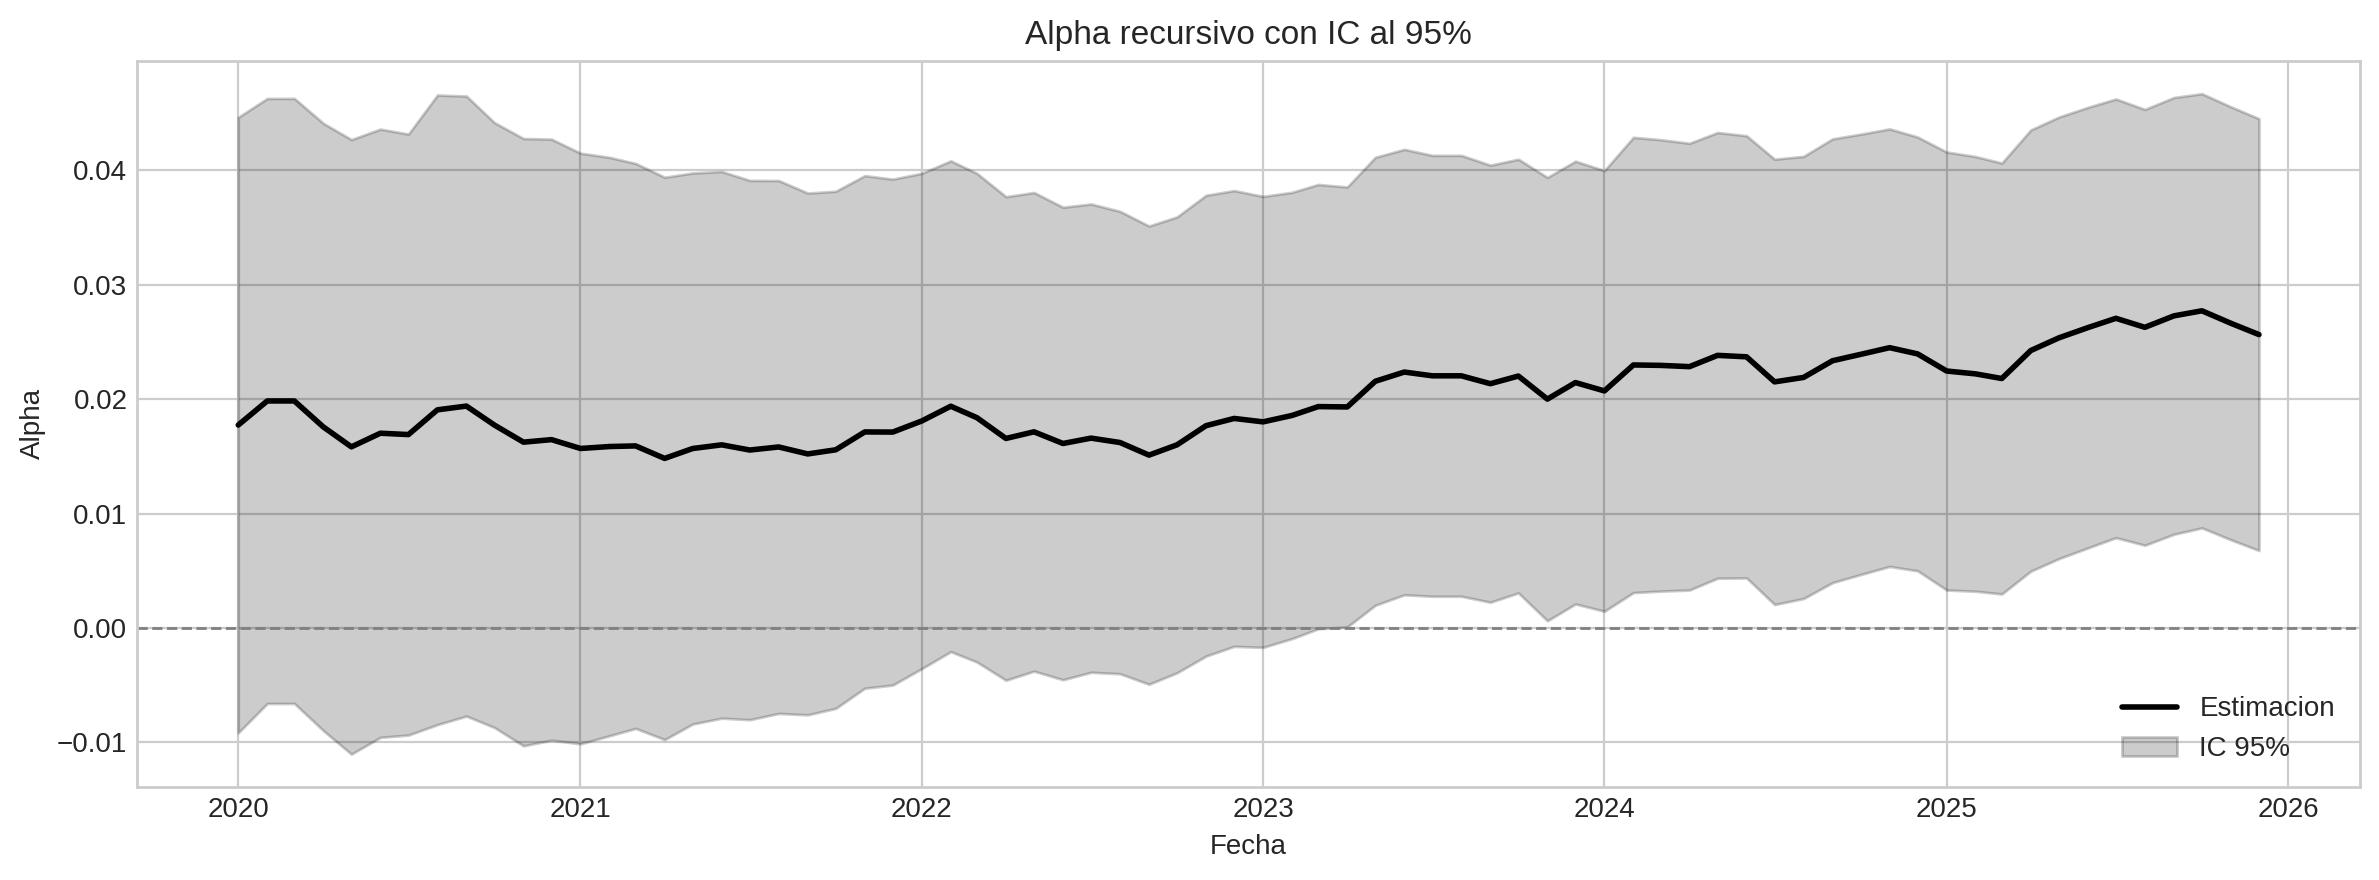

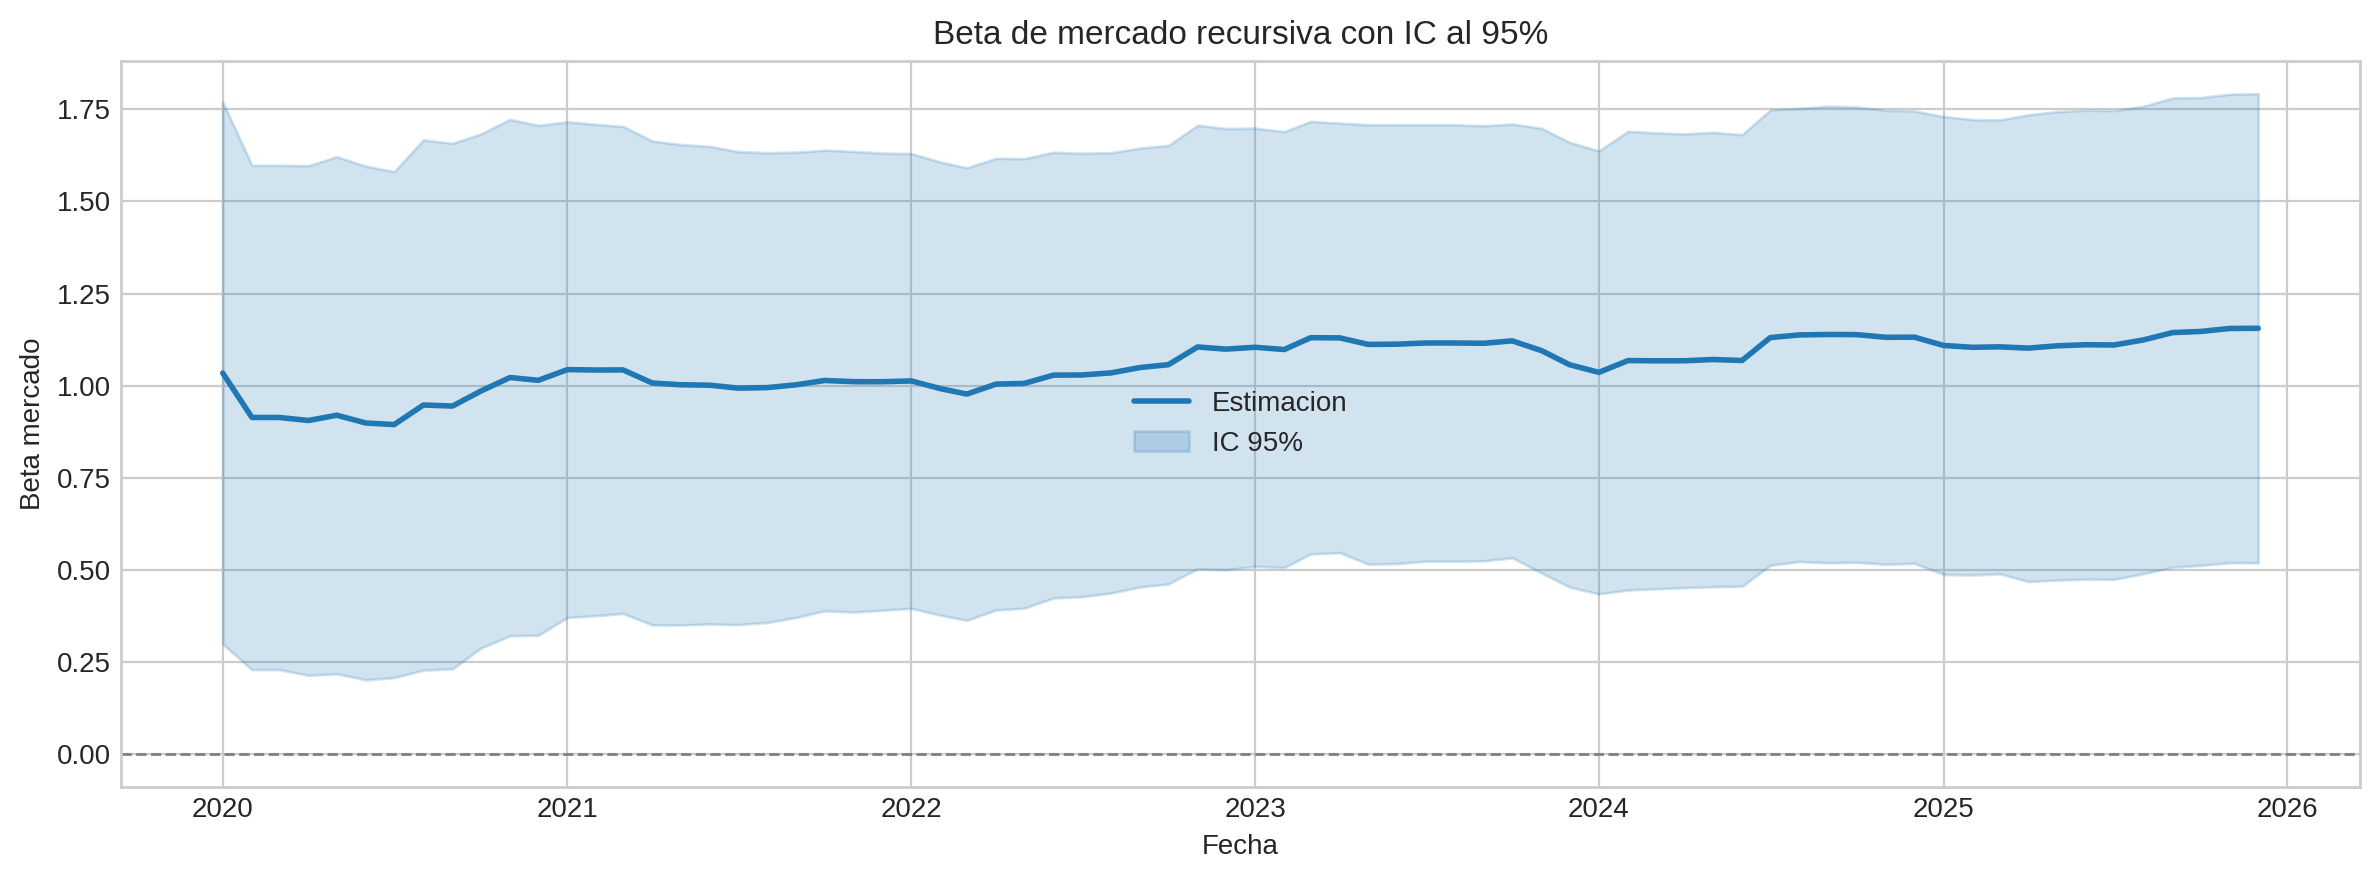

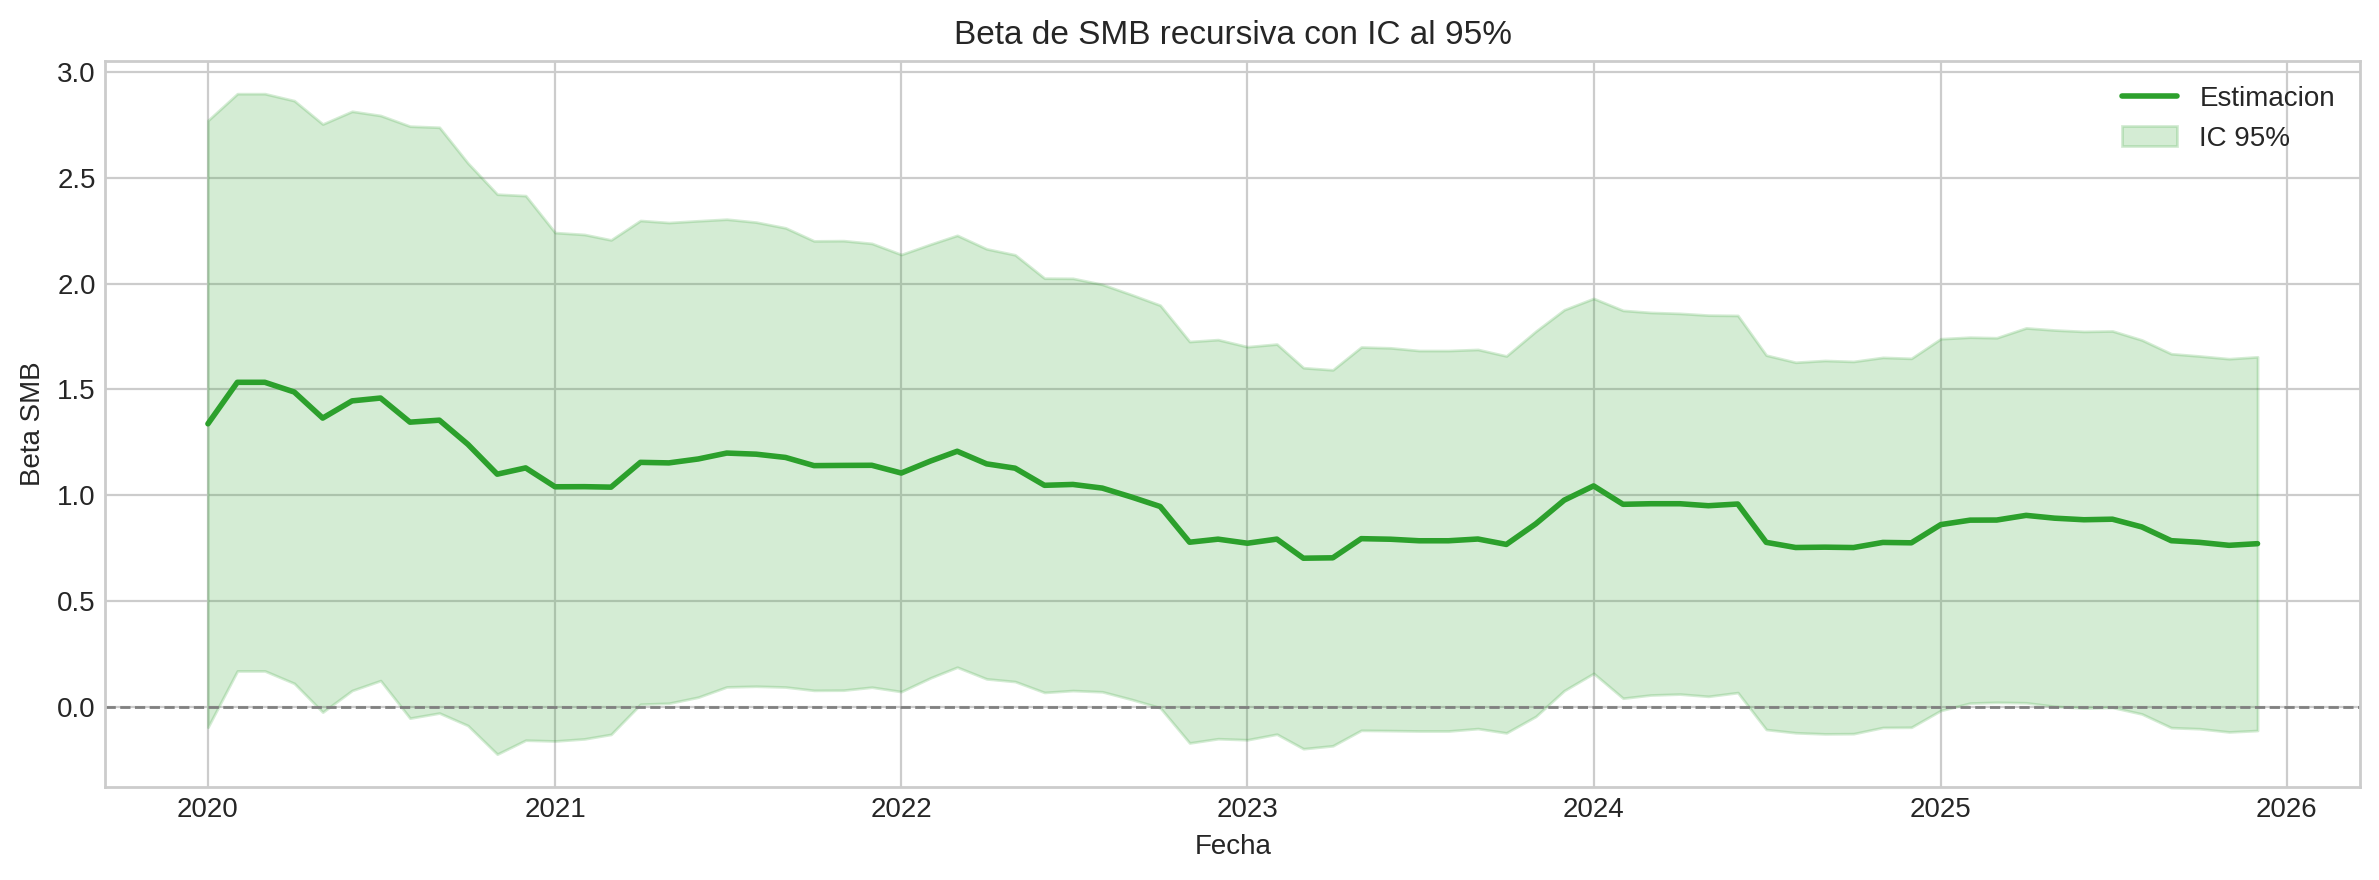

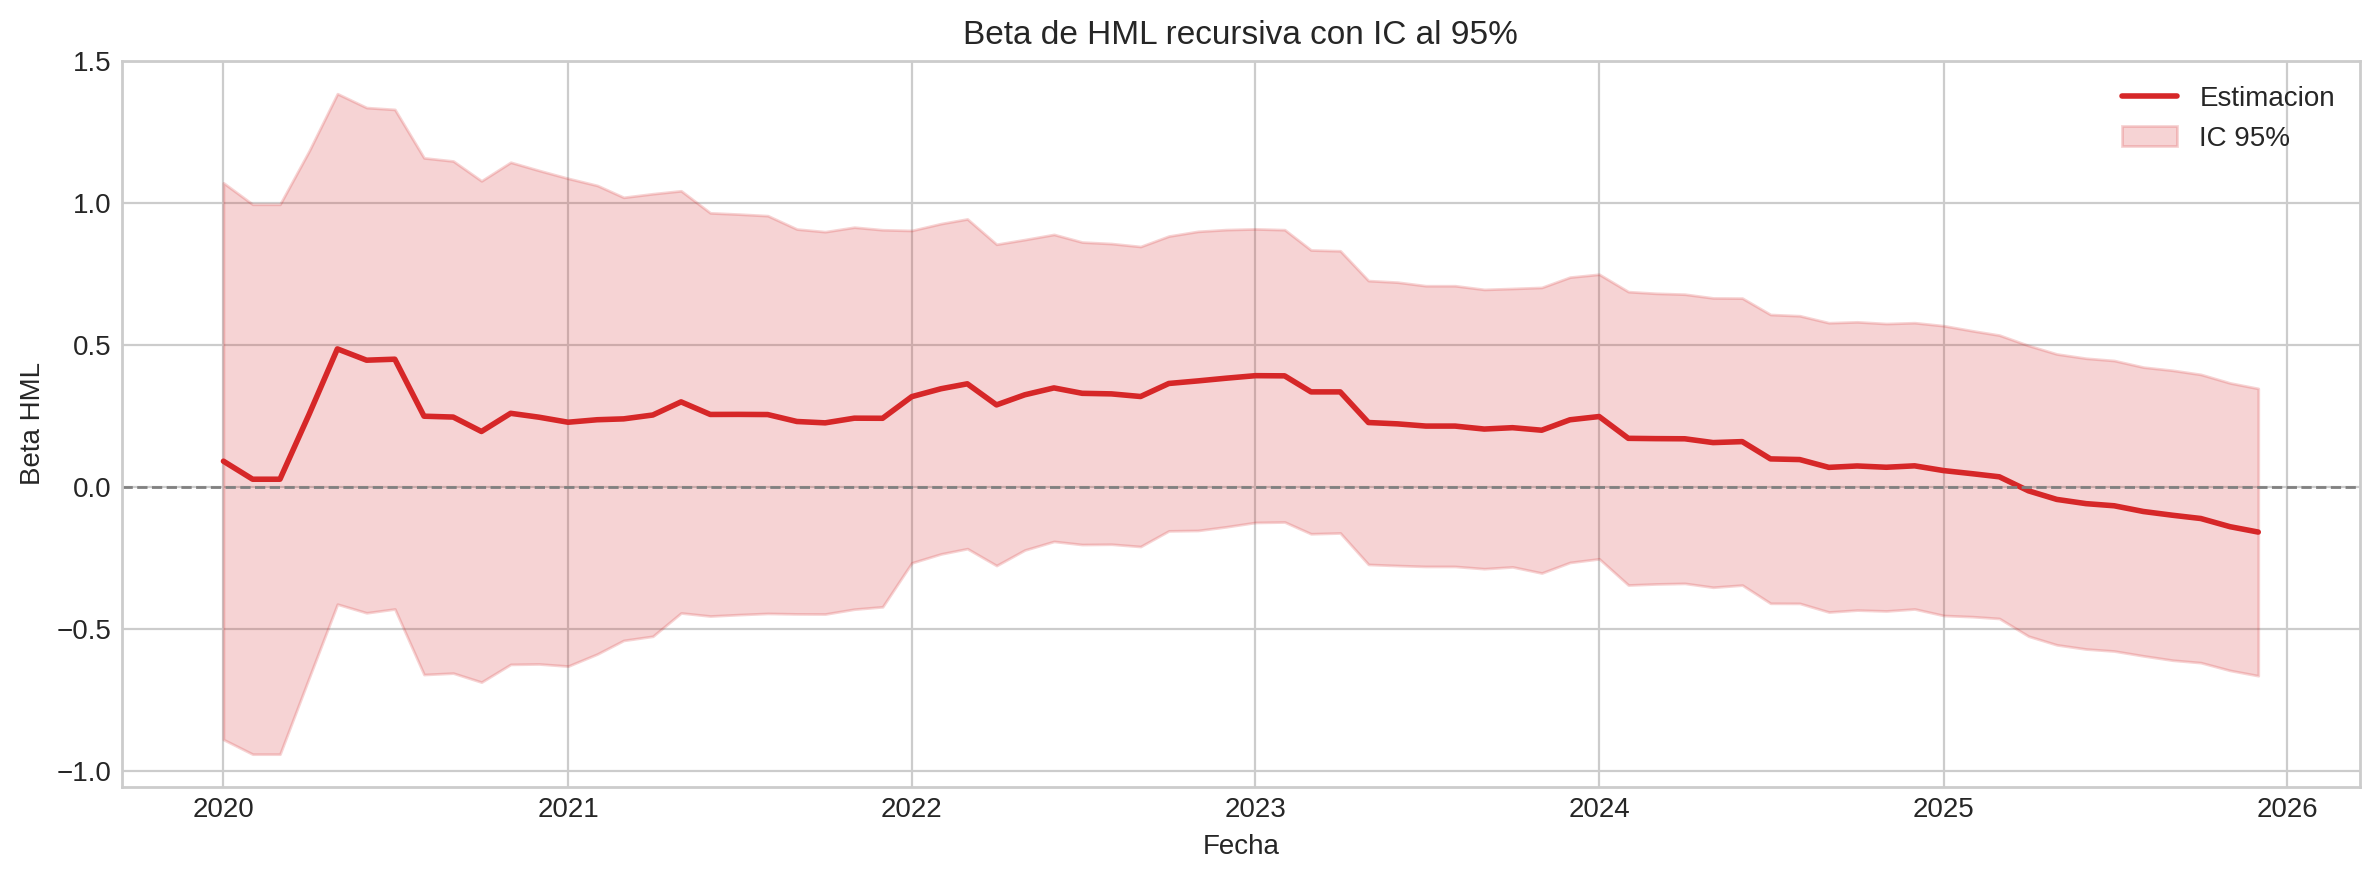

In [94]:
graficar_coeficiente_con_ic(resultados_recursivos, 'const', 'Alpha recursivo con IC al 95%', 'Alpha', 'black')
graficar_coeficiente_con_ic(resultados_recursivos, 'Market Premium', 'Beta de mercado recursiva con IC al 95%', 'Beta mercado', 'tab:blue')
graficar_coeficiente_con_ic(resultados_recursivos, 'SMB', 'Beta de SMB recursiva con IC al 95%', 'Beta SMB', 'tab:green')
graficar_coeficiente_con_ic(resultados_recursivos, 'HML', 'Beta de HML recursiva con IC al 95%', 'Beta HML', 'tab:red')


## 6. Comparacion entre la estimacion estatica y la ultima recursiva


In [95]:
parametros = ['const', 'Market Premium', 'SMB', 'HML', 'intervencion', 'intervencion2', 'intervencion3', 'covid_market']

comparacion = pd.DataFrame({
    'Estatica muestra completa': modelo_ff3_completo.params[parametros],
    'Ultima estimacion recursiva': resultados_recursivos[parametros].iloc[-1]
})

comparacion


,Estatica muestra completa,Ultima estimacion recursiva
const,0.0257,0.0257
Market Premium,1.1558,1.1558
SMB,0.7718,0.7718
HML,-0.1598,-0.1598
intervencion,-0.3277,-0.3277
intervencion2,0.4254,0.4254
intervencion3,0.3757,0.3757
covid_market,-0.0839,-0.0839


## Conclusión Final del Análisis Econométrico de STRL

| Aspecto | Resultado |
|---|---|
| **Beta de mercado** | 1.3086 (mayor riesgo que el Russell 2000) |
| **Alpha** | +2.34% mensual (rentabilidad anormal positiva, significativa) |
| **Heterocedasticidad** | No detectada (BP y White) |
| **Autocorrelación** | No detectada (Ljung-Box, DW) |
| **Normalidad residuos** | Rechazada inicialmente; normalizada con dummies de outlier |
| **Outliers** | Feb-2015 (profit warning), Mar-2015 (rebote), Ago-2023 (resultados récord Q2) |
| **Cambio estructural COVID** | No significativo (Wald F = 0.3522, p = 0.704) |
| **Factores SMB y HML** | No significativos para STRL |
| **Modelo final** | CAPM + OLS estándar + 3 dummies de outlier |
| **R² Ajustado** | 0.422 |
| **Test CAPM conjunto (α=0, β=1)** | Rechazado (F = 5.2913, p = 0.006) |

**Conclusión económica:** Sterling Infrastructure ha generado durante 2015-2025
una rentabilidad sistemáticamente superior a la esperada por el riesgo asumido
según el CAPM. Con una beta de 1.31 es más volátil que el Russell 2000, pero el
alpha positivo y significativo (+2.34% mensual) indica creación de valor más allá
de la compensación por riesgo. Los factores SMB y HML de Fama-French no mejoran
el poder explicativo, por lo que el CAPM de un factor con OLS estándar y corrección
de outliers es la especificación más parsimoniosa y adecuada.